# US Brewery Market Analysis — Final Project
### Finding the Best Location to Open a New Brewery

Group 3: Siyuan Gao, Hanqi Wang, Tianzhi Zhu

**Structure:**
1. Introduction
2. Data Pull
3. Data Quality Checks
4. Feature Engineering
5. SQL Queries
6. EDA
7. Linear Regression
8. Final Ranking & Recommendation
9. Conclusion

---
## 0. Imports

In [2]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sqlite3 as sq
from time import sleep

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

---
## 1. Introduction

The success of investing in a new brewery largely depends on key factors such as its geographical location, sufficient market demand, a favorable competitive environment, and advantageous local socio-economic conditions.

**Target Audience:** Brewery entrepreneurs and investors who are seeking to select new brewery locations in the United States and are looking for a comprehensive, data-driven assessment report of market attractiveness in various states to aid in their decision-making.

**Reason for Analysis:** The US brewery market exhibits significant regional disparities. While some states feature dense clusters of breweries vying for overlapping customer bases, others appear relatively underserved given their population size and income levels. Capturing this geographic variation is essential to evaluating both competitive intensity and unmet demand potential. By leveraging a complete dataset of brewery locations, this analysis seeks to map the distribution of breweries across states and examine its correlation with key socioeconomic factors.

**Data Sources:**
- Main dataset: Open Brewery DB API — US brewery location data
- Outside dataset 1: US Census Bureau API — city-level population and median household income
- Outside dataset 2: Zillow Observed Rent Index (ZORI) — state-level mean rent (2020–2024 average), used as a proxy for commercial real estate costs

**Research Question:** Which US states are the best places to open a new brewery, defined as locations with large populations, high household incomes, low existing brewery competition, and affordable rental costs?

---
## 2. Data Pull

### 2.1 Main Dataset — US Brewery Data

In [3]:
brewery_url = 'https://api.openbrewerydb.org/v1/breweries'

def fetch_openbrewery(
    per_page: int = 200,  # The API caps at 200 results per request, so we loop through pages until it returns nothing.
    max_pages: int | None = None,
    **query_params
) -> pd.DataFrame:
    '''
    Fetch breweries from Open Brewery DB with pagination.

    Args:
        per_page: items per page (API supports per_page; 200 is common max).
        max_pages: stop after this many pages (None = fetch until empty page).
        query_params: additional API query params, e.g. by_state='illinois', by_type='micro'

    Returns:
        DataFrame of breweries.
    '''
    all_rows = []
    page = 1

    while True:
        params = {'page': page, 'per_page': per_page, **query_params}
        resp = requests.get(brewery_url, params=params, timeout=30)

        # Basic error handling
        if resp.status_code != 200:
            raise RuntimeError(f'Request failed: {resp.status_code} - {resp.text[:200]}')

        data = resp.json()

        # Stop when the API returns an empty list (no more pages)
        if not data:
            break

        all_rows.extend(data)

        page += 1
        if max_pages is not None and page > max_pages:
            break

    return pd.DataFrame(all_rows)

# Fetch breweries in the US
brewery_us = fetch_openbrewery(by_country='United States')
brewery_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8175 entries, 0 to 8174
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              8175 non-null   object 
 1   name            8175 non-null   object 
 2   brewery_type    8175 non-null   object 
 3   address_1       7444 non-null   object 
 4   address_2       14 non-null     object 
 5   address_3       0 non-null      object 
 6   city            8175 non-null   object 
 7   state_province  8175 non-null   object 
 8   postal_code     8175 non-null   object 
 9   country         8175 non-null   object 
 10  longitude       5891 non-null   float64
 11  latitude        5891 non-null   float64
 12  phone           7385 non-null   object 
 13  website_url     7057 non-null   object 
 14  state           8175 non-null   object 
 15  street          7444 non-null   object 
dtypes: float64(2), object(14)
memory usage: 1022.0+ KB


After looping through all pages of the Open Brewery DB API, we found 8,126 brewery records located in the United States.

In [4]:
brewery_us.head()

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,longitude,latitude,phone,website_url,state,street
0,5128df48-79fc-4f0f-8b52-d06be54d0cec,(405) Brewing Co,micro,1716 Topeka St,None,None,Norman,Oklahoma,73069-8224,United States,-97.468182,35.257389,4058160490,http://www.405brewing.com,Oklahoma,1716 Topeka St
1,9c5a66c8-cc13-416f-a5d9-0a769c87d318,(512) Brewing Co,micro,407 Radam Ln Ste F200,None,None,Austin,Texas,78745-1197,United States,NaN,NaN,5129211545,http://www.512brewing.com,Texas,407 Radam Ln Ste F200
2,34e8c68b-6146-453f-a4b9-1f6cd99a5ada,1 of Us Brewing Company,micro,8100 Washington Ave,None,None,Mount Pleasant,Wisconsin,53406-3920,United States,-87.883364,42.720108,2624847553,https://www.1ofusbrewing.com,Wisconsin,8100 Washington Ave
3,6d14b220-8926-4521-8d19-b98a2d6ec3db,10 Barrel Brewing Co,large,62970 18th St,None,None,Bend,Oregon,97701-9847,United States,-121.281706,44.086835,5415851007,http://www.10barrel.com,Oregon,62970 18th St
4,e2e78bd8-80ff-4a61-a65c-3bfbd9d76ce2,10 Barrel Brewing Co,large,1135 NW Galveston Ave Ste B,None,None,Bend,Oregon,97703-2465,United States,-121.328802,44.057565,5415851007,None,Oregon,1135 NW Galveston Ave Ste B


### 2.2 Outside Dataset — US Census Data
We use the American Community Survey (ACS) 5-Year data (2020-2024) for city-level **total population** and **median household income**. While 2024 ACS 1-Year estimates provide more temporally precise information, they only cover larger cities, which would substantially reduce spatial coverage and bias the analysis toward large metropolitan areas. Given that population size and income are slow-moving structural variables, we treat the 2020-2024 ACS 5-Year estimates as background socioeconomic conditions.

In [5]:
API_KEY = 'd0ac47581be0fce4a2cea2c71d94176560e14ae0'

def fetch_census_city_acs5(api_key, year=2024):
    '''
    Fetch and clean city population and income from Census ACS 5-Year.
    
    Note:
    - For 2020–2024 ACS 5-Year, set year=2024 and use dataset acs/acs5.
      (Census API uses the ending year for the 5-year vintage.)
    '''
    census_url = f'https://api.census.gov/data/{year}/acs/acs5'
    params = {
        'get': 'NAME,B01003_001E,B19013_001E',  # B01003_001E: Total Population; B19013_001E: Median Household Income
        'for': 'place:*',
        'key': api_key
    }

    response = requests.get(census_url, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()
    df = pd.DataFrame(data[1:], columns=data[0])

    df = df.rename(columns={
        'NAME': 'city_state',
        'B01003_001E': 'total_population',
        'B19013_001E': 'median_household_income',
        'state': 'state_fips',
        'place': 'place_fips'
    })

    # convert data type
    df['total_population'] = pd.to_numeric(df['total_population'], errors='coerce')
    df['median_household_income'] = pd.to_numeric(df['median_household_income'], errors='coerce')

    # split city and state names into two separate columns
    def extract_city_state(name):
        parts = name.split(',')
        city = parts[0].replace(' city', '').replace(' town', '').replace(' village', '').strip()
        state = parts[1].strip() if len(parts) > 1 else None
        return city, state

    df[['city', 'state']] = df['city_state'].apply(lambda x: pd.Series(extract_city_state(x)))

    return df

# 2020–2024 ACS 5-Year vintage (ending year = 2024)
census_2020_2024 = fetch_census_city_acs5(API_KEY, year=2024)
census_2020_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32330 entries, 0 to 32329
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   city_state               32330 non-null  object
 1   total_population         32330 non-null  int64 
 2   median_household_income  32330 non-null  int64 
 3   state_fips               32330 non-null  object
 4   place_fips               32330 non-null  object
 5   city                     32330 non-null  object
 6   state                    32330 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.7+ MB


In [6]:
census_2020_2024.head()

,city_state,total_population,median_household_income,state_fips,place_fips,city,state
0,"Abanda CDP, Alabama",257,115388,01,00100,Abanda CDP,Alabama
1,"Abbeville city, Alabama",2748,31712,01,00124,Abbeville,Alabama
2,"Adamsville city, Alabama",4266,62500,01,00460,Adamsville,Alabama
3,"Addison town, Alabama",649,56384,01,00484,Addison,Alabama
4,"Akron town, Alabama",243,34107,01,00676,Akron,Alabama


### 2.3 Zillow Rent Data
Source: Zillow Observed Rent Index (ZORI), All Homes Plus Multifamily, Metro Level. Downloaded from: https://www.zillow.com/research/data/

To incorporate cost-side considerations into the brewery location analysis, we introduce rental prices as a proxy for local operating costs. Because standardized, publicly available commercial rent data at the national level is limited, we use Zillow’s Metro-level residential rent index (ZORI). While residential and commercial rents are not identical, both reflect underlying regional economic conditions, housing demand, and land scarcity, making ZORI a reasonable proxy for cost-of-location differences across regions.

We use **metro-level (MSA) data rather than city-level rent data** for several reasons:
- Zillow city-level rent data has substantial coverage gaps, with many small cities lacking observations.
- Some states have only one or two cities with available rent data, making city-level aggregation unstable.
- Metropolitan Statistical Areas (MSAs) represent integrated economic regions and better capture housing market conditions than individual city boundaries.

To align with the ACS 5-year census window used elsewhere in the analysis, we compute the **average rent across all available monthly observations from 2020–2024 for each MSA**. We then aggregate to the **state level by taking the mean rent across all MSAs within each state**, producing a consistent state-level cost indicator for subsequent analysis.

In [7]:
# Load Zillow Metro-level ZORI data
zillow_raw = pd.read_csv('Metro_zori_uc_sfrcondomfr_sm_month.csv')

# Keep MSA rows only (drop 'country' row)
zillow_msa = zillow_raw[zillow_raw['RegionType'] == 'msa'].copy()

print(f'MSA rows: {len(zillow_msa)}')
zillow_msa[['RegionName', 'StateName']].head(10)

MSA rows: 720


,RegionName,StateName
1,"New York, NY",NY
2,"Los Angeles, CA",CA
3,"Chicago, IL",IL
4,"Dallas, TX",TX
5,"Houston, TX",TX
6,"Washington, DC",VA
7,"Philadelphia, PA",PA
8,"Miami, FL",FL
9,"Atlanta, GA",GA
10,"Boston, MA",MA


In [8]:
# Select 2020-2024 columns
date_cols = [c for c in zillow_msa.columns
             if any(c.startswith(y) for y in ['2020','2021','2022','2023','2024'])]

# Compute mean rent across 2020-2024 for each MSA (ignore missing months)
zillow_msa['mean_rent'] = zillow_msa[date_cols].mean(axis=1, skipna=True)

# State abbreviation → full name mapping (to match brewery/census format)
abbr_to_state = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California',
    'CO':'Colorado','CT':'Connecticut','DE':'Delaware','DC':'District Of Columbia',
    'FL':'Florida','GA':'Georgia','HI':'Hawaii','ID':'Idaho','IL':'Illinois',
    'IN':'Indiana','IA':'Iowa','KS':'Kansas','KY':'Kentucky','LA':'Louisiana',
    'ME':'Maine','MD':'Maryland','MA':'Massachusetts','MI':'Michigan','MN':'Minnesota',
    'MS':'Mississippi','MO':'Missouri','MT':'Montana','NE':'Nebraska','NV':'Nevada',
    'NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico','NY':'New York',
    'NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma','OR':'Oregon',
    'PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina','SD':'South Dakota',
    'TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont','VA':'Virginia',
    'WA':'Washington','WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming'
}

zillow_msa['state'] = zillow_msa['StateName'].map(abbr_to_state)

# Aggregate to state level: mean across all MSAs in each state
zillow_state = (zillow_msa
    .groupby('state')['mean_rent']
    .mean()
    .reset_index()
)


# DC is excluded — no MSA-level rent data available in Zillow ZORI Metro dataset.
print(f'States with rent data: {len(zillow_state)}')
print(f'Missing: DC excluded (no metro rent data)')
zillow_state.sort_values('mean_rent', ascending=False).head(10)

States with rent data: 50
Missing: DC excluded (no metro rent data)


,state,mean_rent
10,Hawaii,2575.265246
4,California,2040.855941
5,Colorado,1924.693814
20,Massachusetts,1861.737849
29,New Jersey,1768.992699
8,Florida,1699.128667
28,New Hampshire,1674.302453
38,Rhode Island,1672.039478
27,Nevada,1665.841029
6,Connecticut,1656.259971


---
## 3. Data Quality Checks

### 3.1 Missing Data

             count       %
address_3     8175  100.00
address_2     8161   99.83
longitude     2284   27.94
latitude      2284   27.94
website_url   1118   13.68
phone          790    9.66
address_1      731    8.94
street         731    8.94


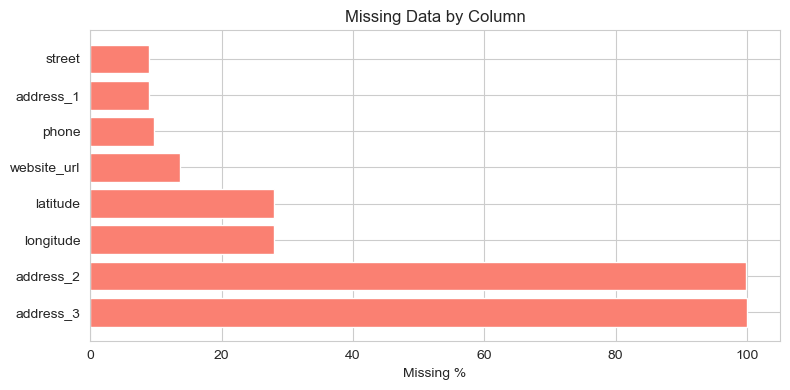

In [9]:
missing = pd.DataFrame({
    'count': brewery_us.isnull().sum(),
    '%': (brewery_us.isnull().sum() / len(brewery_us) * 100).round(2)
})
missing = missing[missing['count'] > 0].sort_values('%', ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing.index, missing['%'], color='salmon')
ax.set_xlabel('Missing %')
ax.set_title('Missing Data by Column')
plt.tight_layout()
plt.show()

Based on the core objective of selecting brewery locations for investors, this analysis will focus on three key fields: brewery_type, state, and city. 
Although the dataset has missing information in fields such as address details, coordinates, and contact information, this information is not necessary for a macro-level assessment of market potential and analysis of the regional competitive landscape. The completeness of the existing data effectively supports key insights into the distribution of breweries, their types, and regional concentration from the state to the city level. This provides a reliable basis for investment decisions.

### 3.2 Oddity & Validity Check
#### 3.2.1 Unique Values

In [10]:
# standardize text formats
brewery_us['state'] = brewery_us['state'].astype(str).str.strip().str.title()
brewery_us['city']  = brewery_us['city'].astype(str).str.strip().str.title()

print('=== brewery_type ===')
print(brewery_us['brewery_type'].value_counts())

print('\n=== state ===')
print(f'Unique states: {brewery_us['state'].nunique()}')
print(brewery_us['state'].value_counts())

print('\n=== city ===')
print(f'Unique cities: {(brewery_us['city']+ '_' + brewery_us['state']).nunique()}')
print((brewery_us['city']+ '_' + brewery_us['state']).value_counts().head(10))

=== brewery_type ===
brewery_type
micro         4156
brewpub       2428
planning       649
closed         348
regional       213
contract       184
large           73
proprietor      68
taproom         34
nano            19
bar              2
location         1
Name: count, dtype: int64

=== state ===
Unique states: 51
state
California              919
Washington              498
Colorado                449
New York                419
Michigan                375
Texas                   352
Pennsylvania            345
Florida                 312
North Carolina          311
Ohio                    303
Oregon                  295
Illinois                257
Virginia                255
Wisconsin               225
Minnesota               183
Massachusetts           164
Indiana                 162
Maryland                158
Missouri                142
Arizona                 125
Tennessee               116
New Jersey              115
Maine                   114
New Hampshire           113
G

**Brewery Types:**
- The US brewing industry is dominated by microbreweries (4,129) and brewpubs (2,424).
- 662 breweries are marked as 'planning' and 318 breweries are marked as 'closed'. These records are retained at this stage to reflect the full competitive landscape and should be handled separately in subsequent analysis.

**Geographic Distribution:**
- These breweries are located in 51 states and territories, with California having the most at 919, followed by Washington and Colorado.
- These breweries are distributed across 3,504 cities (state-city combinations), with Denver having the most breweries at 92, followed closely by San Diego, Seattle and Portland. These high concentrations suggest a unique market dynamic.
- Some cities have unusually high brewery counts relative to their size (e.g., Portland with 85 breweries). This suggests the need for population-adjusted metrics in subsequent analysis.

#### 3.2.2 Data Range

In [11]:
print(f'Longitude range: [{brewery_us['longitude'].min():.2f}, {brewery_us['longitude'].max():.2f}]')
print(f'Latitude range: [{brewery_us['latitude'].min():.2f}, {brewery_us['latitude'].max():.2f}]')

Longitude range: [-159.59, 34.14]
Latitude range: [-86.82, 8411640.79]


In [12]:
brewery_us.sort_values('longitude', ascending=False).head()

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,longitude,latitude,phone,website_url,state,street
3107,7ab0e9c9-ffb3-44e1-91fb-99dc7fd4959d,Goat Island Brewing,micro,1646 A John H Cooper Drive,None,None,Cullman,Alabama,35055-5491,United States,34.140936,-86.820901,2567475556,http://www.goatislandbrewing.com,Alabama,1646 A John H Cooper Drive
4507,aefd86d4-eb51-4aae-bacb-bf1f69025b41,Lubec Brewing Co,brewpub,41 Water St,None,None,Lubec,Maine,04652-,United States,-66.983481,44.860831,2077334555,None,Maine,41 Water St
4550,87f669f2-1318-4fdf-8018-3e590996759d,Machias River Brewing Company,micro,86 Main St,None,None,Machias,Maine,04654-1150,United States,-67.458046,44.714463,2072596001,None,Maine,86 Main St
5184,16b64ce9-966d-4ef8-be16-2fd585f45b9b,Northern Maine Brewing Co,brewpub,22 Main St,None,None,Caribou,Maine,04736-4163,United States,-67.996710,46.814077,2074922185,None,Maine,22 Main St
465,36a6f65e-aa9d-45d5-9ce8-cbbc82ca9ab1,Atlantic Brewing Co / Bar Harbor Brewing,brewpub,52 Cottage Street Bar Harbor,None,None,Bar Harbor,Maine,04609,United States,-68.206071,44.389488,2072884592,http://www.barharborbrewing.com,Maine,52 Cottage Street Bar Harbor


In [13]:
brewery_us.sort_values('latitude', ascending=False).head()

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,longitude,latitude,phone,website_url,state,street
7846,bcc3a506-1067-482c-90a4-0979423987d9,Wasatch Brew Pub - SLC Airport,brewpub,2930 W Terminal Dr,Concourse B Level 2,None,Salt Lake City,Utah,84116,United States,-111.990646,8.411641e+06,8018839033,https://www.saltlakebrewingco.com/wasatch,Utah,2930 W Terminal Dr
6541,fac0abcb-db02-4ec6-845d-457caab0f3ab,Silver Gulch Brewing Co,brewpub,2195 Old Steese Highway,None,None,Fairbanks,Alaska,99712-1023,United States,-147.621976,6.495709e+01,9074522739,http://www.silvergulch.com,Alaska,2195 Old Steese Highway
3649,bd37752a-b7fe-40a2-a9f5-8ed9abcdc97d,HooDoo Brewing Co,micro,1951 Fox Ave,None,None,Fairbanks,Alaska,99701-2701,United States,-147.759820,6.484856e+01,9074592337,http://www.hoodoobrew.com,Alaska,1951 Fox Ave
4793,fec0e3af-f2bd-4b39-ab32-3c30fc0b1e6e,Midnite Mine Brewpub,micro,308 Wendell Ave,None,None,Fairbanks,Alaska,99701-4838,United States,-147.714159,6.484569e+01,9074565348,https://www.facebook.com/midniteminefairbanks,Alaska,308 Wendell Ave
4242,36ec6e41-9a30-4672-83d2-daa3809edca2,Latitude 65 Brewing Company,brewpub,150 Eagle Ave Unit B,None,None,Fairbanks,Alaska,99701-3400,United States,-147.700549,6.484541e+01,9073287748,https://www.lat65brewing.com,Alaska,150 Eagle Ave Unit B


In [14]:
brewery_us.sort_values('latitude').head()

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,longitude,latitude,phone,website_url,state,street
3107,7ab0e9c9-ffb3-44e1-91fb-99dc7fd4959d,Goat Island Brewing,micro,1646 A John H Cooper Drive,None,None,Cullman,Alabama,35055-5491,United States,34.140936,-86.820901,2567475556,http://www.goatislandbrewing.com,Alabama,1646 A John H Cooper Drive
1140,e55300d0-99ac-4968-9d27-8fdd0fd45a85,Bog's Edge Brewing Company,micro,3511 Blarney Rd,None,None,Warrens,Wisconsin,54666-7000,United States,-90.602711,-44.782170,6083436708,http://www.bogsedgebrewing.com,Wisconsin,3511 Blarney Rd
4220,ee3b005d-b4df-418a-8151-c28da97a3731,Lanikai Brewing Co - Volcano,taproom,19-4005 Haunani Rd,None,None,Volcano,Hawaii,96785,United States,-155.235515,19.428646,None,https://www.lanikaibrewing.com,Hawaii,19-4005 Haunani Rd
4136,e1223484-9724-4c6b-ad35-68373f26d91e,Kona Brewing Co - Kona Brewery,regional,74-5588 Pawai Pl,None,None,Kailua Kona,Hawaii,96740-1615,United States,-155.999469,19.642952,8083314331,https://konabrewinghawaii.com/locations/kona-b...,Hawaii,74-5588 Pawai Pl
4137,54b5153a-ae15-47c0-8e81-b58a3ce58d40,Kona Brewing Co - Kona Pub,brewpub,74-5612 Pawai Pl,None,None,Kailua Kona,Hawaii,96740-1617,United States,-155.997661,19.643069,8083342739,https://konabrewinghawaii.com/locations/kona-pub,Hawaii,74-5612 Pawai Pl


**Geographic Coordinate:**
- **Oddity**: one record has a positive longitude (34.14) and two extremely low latitudes (−86.82 and -44.78), which would place the location far outside the United States. Another record has a latitude above 8 million, indicating a unit or data-entry error.
- Because coordinates are only used for map-based visualization, not for the core city/state-level market analysis, we **do not drop** these rows from the main dataset. Instead, we exclude them when creating the coordinate subset used for plotting and treat these values as invalid coordinates when cleaning in Part 3.3. This prevents a few erroneous points from distorting the map while preserving all observations for aggregation by city and state.

#### 3.2.3 Visual — Coordinates

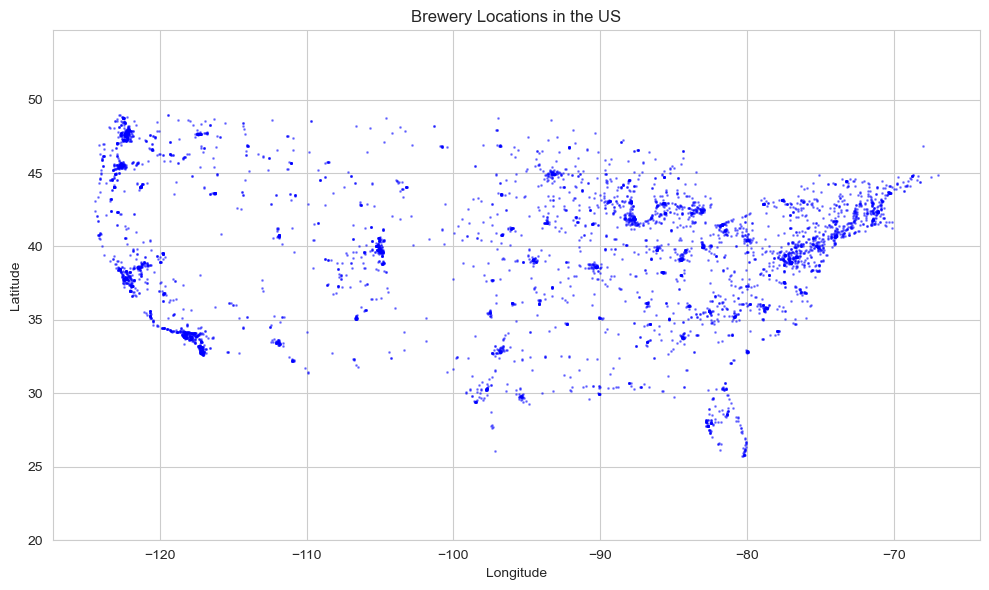

In [15]:
# Filtered to a reasonable coordinate range (within the United States) ONLY for mapping
us_bounds = {
    'lon_min': -125, 'lon_max': -65,
    'lat_min': 25, 'lat_max': 50
}

coord_df = brewery_us.dropna(subset=['latitude', 'longitude']).copy()
coord_df = coord_df[
    (coord_df['longitude'].between(us_bounds['lon_min'], us_bounds['lon_max'])) &
    (coord_df['latitude'].between(us_bounds['lat_min'], us_bounds['lat_max']))
]

# Set appropriate axis ranges when plotting the graph.
plt.figure(figsize=(10, 6))
plt.scatter(coord_df['longitude'], coord_df['latitude'], s=1, alpha=0.4, color='blue')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Brewery Locations in the US')
plt.axis('equal')  
plt.tight_layout()
plt.show()

States loaded: 49
Columns: ['name', 'cartodb_id', 'created_at', 'updated_at', 'geometry']


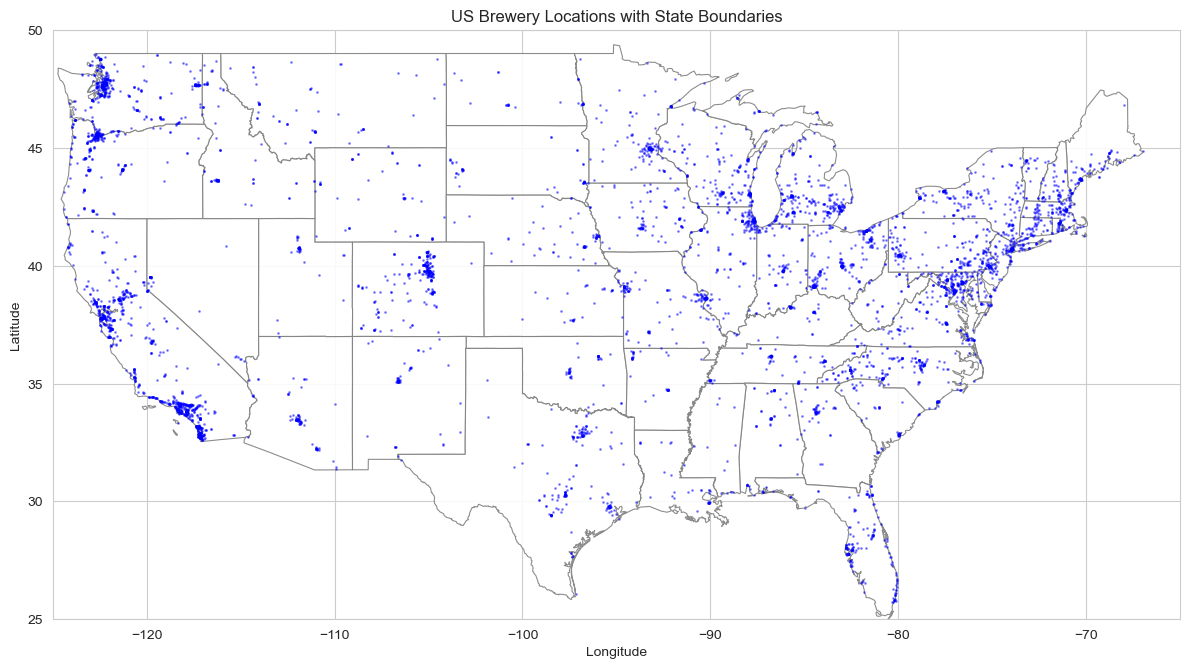

In [16]:
# Load US states boundary data from Natural Earth (simplified version)
# This uses a reliable online source with proper state boundaries
states_gdf = gpd.read_file('https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/united-states.geojson')

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot state boundaries
states_gdf.plot(
    ax=ax,
    color='white',      
    edgecolor='gray',    
    linewidth=0.8,      
    alpha=0.9        
)

# Plot the brewery data points
ax.scatter(
    coord_df['longitude'], 
    coord_df['latitude'], 
    s=1,               
    alpha=0.4,       
    color='blue'        
)

# Set the display range (continental US)
ax.set_xlim(-125, -65)
ax.set_ylim(25, 50)

# Add labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US Brewery Locations with State Boundaries')

# Optional: Show state names
print('States loaded:', len(states_gdf))
print('Columns:', states_gdf.columns.tolist())

plt.tight_layout()
plt.show()

**Geographic Distribution:**
- The brewery geographic distribution after filtering aligns well with known population centers in the continental United States, no obvious geographic data errors beyond the coordinate oddities, providing visual confirmation of coordinate data validity.
- Visual inspection confirms breweries cluster in major metro areas (West Coast, Northeast, Colorado). This spatial pattern matches known craft beer culture centers.

### 3.3 Clean

Since Section 3.1 shows that `city` and `state` contain no missing values, no rows are removed. The cleaning steps here focus on standardizing text formats and flagging invalid coordinates.

In [17]:
brewery_clean = brewery_us.copy()

# Clean core geographic fields
brewery_clean['state'] = brewery_clean['state'].astype(str).str.strip().str.title()
brewery_clean['city']  = brewery_clean['city'].astype(str).str.strip().str.title()

# Flag invalid coordinates and set to NA
brewery_clean['latitude']  = pd.to_numeric(brewery_clean['latitude'],  errors='coerce')
brewery_clean['longitude'] = pd.to_numeric(brewery_clean['longitude'], errors='coerce')

has_coord = brewery_clean['latitude'].notna() & brewery_clean['longitude'].notna()

invalid_coord_mask = has_coord & (
    (brewery_clean['longitude'] > 0) |                  # US longitudes should be negative (in this dataset scope)
    (brewery_clean['latitude'] < 0)  |                  # US latitudes should be positive
    (~brewery_clean['latitude'].between(-90, 90)) |     # latitude must be in [-90, 90]
    (~brewery_clean['longitude'].between(-180, 180))    # longitude must be in [-180, 180]
)

brewery_clean.loc[invalid_coord_mask, ['latitude', 'longitude']] = pd.NA    # set invalid coords to NA


brewery_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8175 entries, 0 to 8174
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              8175 non-null   object 
 1   name            8175 non-null   object 
 2   brewery_type    8175 non-null   object 
 3   address_1       7444 non-null   object 
 4   address_2       14 non-null     object 
 5   address_3       0 non-null      object 
 6   city            8175 non-null   object 
 7   state_province  8175 non-null   object 
 8   postal_code     8175 non-null   object 
 9   country         8175 non-null   object 
 10  longitude       5888 non-null   float64
 11  latitude        5888 non-null   float64
 12  phone           7385 non-null   object 
 13  website_url     7057 non-null   object 
 14  state           8175 non-null   object 
 15  street          7444 non-null   object 
dtypes: float64(2), object(14)
memory usage: 1022.0+ KB


The data cleaning process verified the completeness of the dataset regarding key geographical information. The original and the cleaned dataset both contained 8,126 records. The data quality is completely reliable in terms of core geographical dimensions and providing a complete data foundation for subsequent location analysis based on states and cities.

### 3.4 Census Data Check

In [18]:
print('=== Census Data ===')
print(f'Cities: {len(census_2020_2024)}')
print(f'Missing values: {census_2020_2024.isnull().sum().to_dict()}')
print()
census_2020_2024.describe()

=== Census Data ===
Cities: 32330
Missing values: {'city_state': 0, 'total_population': 0, 'median_household_income': 0, 'state_fips': 0, 'place_fips': 0, 'city': 0, 'state': 0}



,total_population,median_household_income
count,3.233000e+04,3.233000e+04
mean,7.875821e+03,-7.956999e+07
std,6.593666e+04,2.162440e+08
min,0.000000e+00,-6.666667e+08
25%,2.770000e+02,4.484400e+04
50%,9.590000e+02,6.281300e+04
75%,3.780500e+03,8.587425e+04
max,8.483844e+06,2.500010e+05


**Census Data:**
- **Oddity**: The Census API returns negative values (e.g., -66666666) in the median_household_income field to indicate missing or unavailable data. These values should be treated as NA.

In [19]:
# Replace negative income values with NA
census_2020_2024.loc[census_2020_2024['median_household_income'] < 0, 'median_household_income'] = pd.NA

### 3.5 Zillow Data Quality Check

In [20]:
print('=== Zillow State-Level Rent Data ===')
print(f'States: {len(zillow_state)}')
print(f'Missing values: {zillow_state.isnull().sum().to_dict()}')
print(f'Rent range: ${zillow_state["mean_rent"].min():.0f} — ${zillow_state["mean_rent"].max():.0f}')
print(f'Mean rent: ${zillow_state["mean_rent"].mean():.0f}')
print()
zillow_state.describe()

=== Zillow State-Level Rent Data ===
States: 50
Missing values: {'state': 0, 'mean_rent': 0}
Rent range: $920 — $2575
Mean rent: $1366



,mean_rent
count,50.000000
mean,1366.399508
std,331.517793
min,920.222480
25%,1108.601325
50%,1319.264472
75%,1551.782545
max,2575.265246


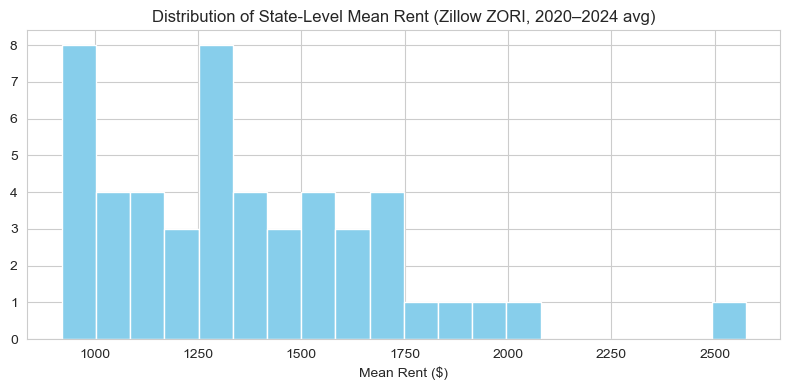

In [21]:
# Visual check: rent distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(zillow_state['mean_rent'], bins=20, color='skyblue', edgecolor='white')
ax.set_xlabel('Mean Rent ($)')
ax.set_title('Distribution of State-Level Mean Rent (Zillow ZORI, 2020–2024 avg)')
plt.tight_layout()
plt.show()

The summary statistics indicate that the state-level rent data covers 50 states (with Washington, DC excluded due to missing metro-level observations). No missing values are present after aggregation.

The rent values range from approximately **$920 to $2,575**, which is consistent with expected geographic variation in housing costs across the United States. Higher rents are observed in high-cost states such as Hawaii and California, while lower rents appear in less expensive housing markets.

No implausible or extreme values are detected, and the distribution appears moderately right-skewed due to a small number of high-cost states. Since these values reflect genuine market differences rather than data errors, **no additional cleaning or outlier treatment is applied**, and the dataset is considered ready for merging with the main analysis dataset.

---
## 4. Feature Engineering

### 4.1 Merge Census Data

#### 4.1.1 State-Level Aggregation & Merge

In [22]:
census_2020_2024['state'] = census_2020_2024['state'].astype(str).str.strip().str.title()

# Aggregate brewery counts by state
state_brewery_agg = brewery_clean.groupby('state').agg(
    total_breweries = ('id', 'count'),  # total breweries
    brewery_type_count = ('brewery_type', lambda x: x.value_counts().to_dict())  # brewery_type distribution
).reset_index()

# Aggregate census data to state level
state_census = census_2020_2024.groupby('state').agg({
    'total_population': 'sum',
    'median_household_income': 'median'
}).reset_index()

# Merge
state_data = state_brewery_agg.merge(state_census, on='state', how='left')

print(f'State-level data shape: {state_data.shape}')
print(f'Missing census data for {state_data['total_population'].isna().sum()} states')

State-level data shape: (51, 5)
Missing census data for 0 states


51 states are matched. No state data is missing after merging.

In [23]:
state_data.head()

,state,total_breweries,brewery_type_count,total_population,median_household_income
0,Alabama,52,"{'micro': 26, 'closed': 15, 'brewpub': 5, 'pla...",3418068,54871.0
1,Alaska,60,"{'micro': 28, 'brewpub': 18, 'closed': 7, 'tap...",719076,67500.0
2,Arizona,125,"{'micro': 59, 'brewpub': 46, 'planning': 13, '...",6900619,59768.5
3,Arkansas,45,"{'micro': 22, 'brewpub': 18, 'planning': 4, 'c...",2146827,49449.5
4,California,919,"{'micro': 466, 'brewpub': 254, 'planning': 64,...",37513430,89250.0


#### 4.1.2 City-Level Aggregation & Merge

In [24]:
census_2020_2024['city'] = census_2020_2024['city'].astype(str).str.strip().str.title()

# Aggregate brewery counts by city
city_brewery_agg = brewery_clean.groupby(['state', 'city']).agg(
    total_breweries=('id', 'count'),
    brewery_type_count=('brewery_type', lambda x: x.value_counts().to_dict())
).reset_index()

# Merge
city_data = city_brewery_agg.merge(
    census_2020_2024[[
    'state',
    'city',
    'total_population',
    'median_household_income']],
    on=['state', 'city'], how='left')

print(f'State-level data shape: {city_data.shape}')
print(f'Missing census data for {city_data['total_population'].isna().sum()} cities')

State-level data shape: (3517, 6)
Missing census data for 1004 cities


Despite using the ACS 5-Year dataset, 994 cities remained unmatched. This may be due to differences in naming conventions and breweries located at Census Designated Sites (CDPs) not being covered by major location-level API calls. Therefore, these unmatched cities are treated as missing values and we focus more on the **state level** where data is 100% complete.

### 4.2 Create Ratios & Interaction Terms
- Brewery Density: measures the supply-side concentration by showing how many breweries exist for every 100,000 residents in a given area.
- People per Brewery: measures the market potential or demand-side availability by showing the average number of potential customers served by a single brewery, making it easier to identify underserved markets.
- Median Income per Brewery: measures the potential consumer purchasing power to each brewery.
- Weighted Average Income: calculates the state-level economic capacity by weighting local median incomes by population, providing a more accurate representation of total purchasing power available in a region than a simple average.

In [25]:
# 4.2.1 Brewery Density
state_data['breweries_per_100k'] = (
    state_data['total_breweries'] / state_data['total_population'] * 100000
)

# 4.2.2 People per Brewery
state_data['people_per_brewery'] = (
    state_data['total_population'] / state_data['total_breweries']
)

# 4.2.3 Median Income per Brewery
state_data['income_per_brewery'] = (
    state_data['median_household_income'] / state_data['total_breweries']
)

# 4.2.4 Weighted Average Income
income_clean = census_2020_2024.copy()
income_clean['income*population'] = income_clean['median_household_income'] * income_clean['total_population']
state_income = income_clean.groupby('state').agg({
    'income*population': 'sum',
    'total_population': 'sum'
}).reset_index()
state_income['weighted_average_income'] = state_income['income*population'] / state_income['total_population']

state_data = state_data.merge(
        state_income[['state', 'weighted_average_income']], 
        on='state', 
        how='left')

# Top 5 states with large population ratio and high income ratio
print('=== Top 5 States with Lowest Brewery Density & Highest People per Brewery ===')
print(state_data.nsmallest(5, 'breweries_per_100k')[['state', 'breweries_per_100k', 'people_per_brewery']])
print('\n=== Top 5 States with Highest Median Income per Brewery ===')
print(state_data.nlargest(5, 'income_per_brewery')[['state', 'income_per_brewery']])
print('\n=== Top 5 States with Highest Weighted Average Income ===')
print(state_data.nlargest(5, 'weighted_average_income')[['state', 'weighted_average_income']])

=== Top 5 States with Lowest Brewery Density & Highest People per Brewery ===
          state  breweries_per_100k  people_per_brewery
24  Mississippi            1.027354        97337.470588
36     Oklahoma            1.370394        72971.727273
44         Utah            1.380070        72460.088889
18    Louisiana            1.476830        67712.613636
43        Texas            1.512078        66134.150568

=== Top 5 States with Highest Median Income per Brewery ===
                   state  income_per_brewery
8   District Of Columbia         4994.090909
39          Rhode Island         3136.580645
7               Delaware         2834.821429
11                Hawaii         2790.029412
24           Mississippi         2788.000000

=== Top 5 States with Highest Weighted Average Income ===
                   state  weighted_average_income
8   District Of Columbia            109870.000000
20              Maryland            109285.054532
46              Virginia            106075.459

High-density markets often correspond to mature consumer bases and fierce competition. States such as Mississippi, Oklahoma, and Utah show the lowest brewery density and the highest number of people per brewery, indicating relatively low competition and strong potential for new market entry. The District of Columbia and Rhode Island stand out by dominating both Median Income per Brewery and Weighted Average Income. This suggests that while these markets may be more competitive, they possess significantly higher concentrated purchasing power and a wealthier consumer base. Together, these results highlight a strategic trade-off between low competition and high income when identifying attractive states for opening a new brewery.

### 4.3 Region Feature (OHE)
This region feature is used in subsequent EDA to compare market opportunities across regions.

In [26]:
region_map = {
    'Northeast': ['Maine','New Hampshire','Vermont','Massachusetts','Rhode Island',
                  'Connecticut','New York','New Jersey','Pennsylvania'],
    'Southeast': ['Delaware','Maryland','Virginia','West Virginia','North Carolina',
                  'South Carolina','Georgia','Florida','Kentucky','Tennessee',
                  'Alabama','Mississippi','Arkansas','Louisiana', 'District Of Columbia'],
    'Midwest':   ['Ohio','Indiana','Illinois','Michigan','Wisconsin','Minnesota',
                  'Iowa','Missouri','North Dakota','South Dakota','Nebraska','Kansas'],
    'Southwest': ['Oklahoma','Texas','New Mexico','Arizona'],
    'West':      ['Montana','Idaho','Wyoming','Colorado','Utah','Nevada',
                  'California','Oregon','Washington','Alaska','Hawaii']
}
state_to_region = {s: r for r, states in region_map.items() for s in states}

# Map regions
state_data['region'] = state_data['state'].map(state_to_region)
brewery_clean['region'] = brewery_clean['state'].map(state_to_region)

# Check unmapped states
unmapped_states = sorted(state_data.loc[state_data['region'].isna(), 'state'].unique())
print(f'Unmapped states/areas in state_data: {unmapped_states}')

Unmapped states/areas in state_data: []


In [27]:
# Use .map() to simplify brewery types into broader group. This makes it easier to compare market segments at a high level
type_simplify = {
    'micro':       'Production',
    'regional':    'Production',
    'large':       'Production',
    'brewpub':     'Brewpub',
    'taproom':     'Brewpub',
    'planning':    'Pre-market',
    'closed':      'Closed',
    'contract':    'Other',
    'proprietary': 'Other'
}
brewery_clean['type_group'] = brewery_clean['brewery_type'].map(type_simplify)

# Summary table: brewery count by simplified type group
type_group_summary = (
    brewery_clean.groupby('type_group')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'brewery_count'})
    .sort_values('brewery_count', ascending=False)
)
print(type_group_summary)

   type_group  brewery_count
4  Production           4442
0     Brewpub           2462
3  Pre-market            649
1      Closed            348
2       Other            184


All states are mapped to regions.

In [28]:
# One hot encoding
region_OHE = pd.get_dummies(state_data['region'], prefix='region', drop_first=False)
state_data = pd.concat([state_data, region_OHE], axis=1)

state_data.head()

,state,total_breweries,brewery_type_count,total_population,median_household_income,breweries_per_100k,people_per_brewery,income_per_brewery,weighted_average_income,region,region_Midwest,region_Northeast,region_Southeast,region_Southwest,region_West
0,Alabama,52,"{'micro': 26, 'closed': 15, 'brewpub': 5, 'pla...",3418068,54871.0,1.521327,65732.076923,1055.211538,67313.745276,Southeast,False,False,True,False,False
1,Alaska,60,"{'micro': 28, 'brewpub': 18, 'closed': 7, 'tap...",719076,67500.0,8.344042,11984.600000,1125.000000,93355.399874,West,False,False,False,False,True
2,Arizona,125,"{'micro': 59, 'brewpub': 46, 'planning': 13, '...",6900619,59768.5,1.811432,55204.952000,478.148000,83511.734264,Southwest,False,False,False,True,False
3,Arkansas,45,"{'micro': 22, 'brewpub': 18, 'planning': 4, 'c...",2146827,49449.5,2.096117,47707.266667,1098.877778,61773.545193,Southeast,False,False,True,False,False
4,California,919,"{'micro': 466, 'brewpub': 254, 'planning': 64,...",37513430,89250.0,2.449789,40819.836779,97.116431,104267.424981,West,False,False,False,False,True


### 4.4 Outlier Check
- We only check `breweries_per_100k`, `people_per_brewery`, `income_per_brewery`, `weighted_average_income` and do not check `total_population`, `median_household_income`, `total_breweries` because these `outliers` often represent real-world large/small states.
- Given the small sample size at the state level and the presence of genuine structural extremes, we examine tail behavior using selected percentiles (1%, 5%, 95%, 99%) rather than applying IQR-based rules, which may incorrectly flag meaningful markets as outliers.

In [29]:
state_data.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,total_breweries,total_population,median_household_income,breweries_per_100k,people_per_brewery,income_per_brewery,weighted_average_income
count,51.000000,5.100000e+01,51.000000,51.000000,51.000000,51.000000,51.000000
mean,160.294118,4.955344e+06,71281.617647,4.831004,33675.147860,1001.252604,80359.012621
std,166.787685,6.456476e+06,16341.143690,4.256123,20937.230172,965.248729,14582.424088
min,17.000000,2.785180e+05,47396.000000,1.027354,4720.644068,97.116431,54917.474151
1%,19.500000,3.590865e+05,48422.750000,1.198874,5284.140618,130.856215,55831.560353
5%,27.000000,5.440985e+05,52967.000000,1.428450,7225.264111,177.657557,60251.461767
50%,94.000000,3.210756e+06,67500.000000,3.467282,28841.032967,696.325301,76956.522094
95%,434.000000,1.680017e+07,106100.250000,14.332199,70086.351263,2812.425420,105431.455158
99%,708.500000,3.039633e+07,109287.250000,19.142237,85154.598930,4065.335777,109577.527266
max,919.000000,3.751343e+07,109870.000000,21.183550,97337.470588,4994.090909,109870.000000


The numeric inspection shows that all ratio features are right-skewed, with a small number of states exhibiting very high or very low values. These extremes reflect genuine market conditions (e.g., small-population or high-income states) rather than data errors. Therefore, **no observations are removed**; instead, log(1 + x) transformations are applied to reduce skewness while preserving the full set of states.

#### 4.4.2 Log Transform

In [30]:
normalize_features = [
    'log_breweries_per_100k',
    'log_people_per_brewery',
    'log_income_per_brewery',
    'log_weighted_average_income'
]

state_data['log_breweries_per_100k'] = np.log1p(state_data['breweries_per_100k'])
state_data['log_people_per_brewery'] = np.log1p(state_data['people_per_brewery'])
state_data['log_income_per_brewery'] = np.log1p(state_data['income_per_brewery'])
state_data['log_weighted_average_income'] = np.log1p(state_data['weighted_average_income'])

state_data[normalize_features].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,log_breweries_per_100k,log_people_per_brewery,log_income_per_brewery,log_weighted_average_income
count,51.000000,51.000000,51.000000,51.000000
mean,1.582433,10.209409,6.510148,11.278581
std,0.566740,0.708385,0.925277,0.177955
min,0.706731,8.459912,4.586155,10.913605
1%,0.784894,8.566938,4.847853,10.929978
5%,0.887055,8.868021,5.185300,11.005980
50%,1.496780,10.269589,6.547252,11.251009
95%,2.714731,11.156924,7.942126,11.565807
99%,2.997657,11.341895,8.283709,11.604393
max,3.099351,11.485950,8.516211,11.607062


In [31]:
print("=== breweries_per_100k === ")
print("Original:")
print(f"  Skewness: {state_data['breweries_per_100k'].skew():.2f}")
print(f"  Range: [{state_data['breweries_per_100k'].min():.2f}, {state_data['breweries_per_100k'].max():.2f}]")
print("Log-transformed:")
print(f"  Skewness: {state_data['log_breweries_per_100k'].skew():.2f}")
print(f"  Range: [{state_data['log_breweries_per_100k'].min():.2f}, {state_data['log_breweries_per_100k'].max():.2f}]")

print("\n=== people_per_brewery === ")
print("Original:")
print(f"  Skewness: {state_data['people_per_brewery'].skew():.2f}")
print(f"  Range: [{state_data['people_per_brewery'].min():.2f}, {state_data['people_per_brewery'].max():.2f}]")
print("Log-transformed:")
print(f"  Skewness: {state_data['log_people_per_brewery'].skew():.2f}")
print(f"  Range: [{state_data['log_people_per_brewery'].min():.2f}, {state_data['log_people_per_brewery'].max():.2f}]")

print("\n=== income_per_brewery === ")
print("Original:")
print(f"  Skewness: {state_data['income_per_brewery'].skew():.2f}")
print(f"  Range: [{state_data['income_per_brewery'].min():.2f}, {state_data['income_per_brewery'].max():.2f}]")
print("Log-transformed:")
print(f"  Skewness: {state_data['log_income_per_brewery'].skew():.2f}")
print(f"  Range: [{state_data['log_income_per_brewery'].min():.2f}, {state_data['log_income_per_brewery'].max():.2f}]")

print("\n=== weighted_average_income === ")
print("Original:")
print(f"  Skewness: {state_data['weighted_average_income'].skew():.2f}")
print(f"  Range: [{state_data['weighted_average_income'].min():.2f}, {state_data['weighted_average_income'].max():.2f}]")
print("Log-transformed:")
print(f"  Skewness: {state_data['log_weighted_average_income'].skew():.2f}")
print(f"  Range: [{state_data['log_weighted_average_income'].min():.2f}, {state_data['log_weighted_average_income'].max():.2f}]")

=== breweries_per_100k === 
Original:
  Skewness: 2.23
  Range: [1.03, 21.18]
Log-transformed:
  Skewness: 0.84
  Range: [0.71, 3.10]

=== people_per_brewery === 
Original:
  Skewness: 0.86
  Range: [4720.64, 97337.47]
Log-transformed:
  Skewness: -0.55
  Range: [8.46, 11.49]

=== income_per_brewery === 
Original:
  Skewness: 2.06
  Range: [97.12, 4994.09]
Log-transformed:
  Skewness: -0.01
  Range: [4.59, 8.52]

=== weighted_average_income === 
Original:
  Skewness: 0.54
  Range: [54917.47, 109870.00]
Log-transformed:
  Skewness: 0.22
  Range: [10.91, 11.61]


After applying log(1 + x) transformations, the distributions of all ratio features become substantially more symmetric, with reduced dispersion and no extreme tail behavior. As a result, **no further outlier treatment is required**, and all states are retained for subsequent analysis.

### 4.5 Normalize — Min–Max Scaling
To enable meaningful comparison across features with different scales, we apply Min–Max normalization to the log-transformed ratio features. This rescales all metrics to the [0, 1] range while preserving their relative ordering, facilitating cross-state comparison.

In [32]:
scaler = MinMaxScaler()

state_data[[f"{c}_norm" for c in normalize_features]] = scaler.fit_transform(
    state_data[normalize_features]
)

state_data[[
    'state',
    'log_breweries_per_100k_norm',
    'log_people_per_brewery_norm',
    'log_income_per_brewery_norm',
    'log_weighted_average_income_norm'
]].head()

,state,log_breweries_per_100k_norm,log_people_per_brewery_norm,log_income_per_brewery_norm,log_weighted_average_income_norm
0,Alabama,0.091136,0.870262,0.604645,0.293500
1,Alaska,0.638634,0.307844,0.620925,0.765115
2,Arizona,0.136655,0.812585,0.403520,0.604434
3,Arkansas,0.176968,0.764349,0.614953,0.169645
4,California,0.222176,0.712825,0.000000,0.924525


---
## 5. SQL Queries

We load the cleaned brewery, census, and Zillow data into a SQLite database as separate tables, then use SQL to merge them and apply window functions for regional comparison. 

### 5.1 Connect to SQLite
All SQL queries below run against a single database, making joins / group-bys / window functions reproducible.

In [33]:
db_path = "brewery_analysis.db"
conn = sq.connect(db_path)
cursor = conn.cursor()

print(f"Connected to SQLite: {db_path}")

Connected to SQLite: brewery_analysis.db


### 5.2 Load Cleaned Tables into SQLite
Create three base tables in SQLite: `brewery_agg`, `census_agg`, `zillow_rent` by aggregating brewery to state level; selecting needed census columns; loading all three via `to_sql(replace)`.

In [34]:
# Prepare upload DataFrames (state-level)
brewery_upload = brewery_clean.groupby(["state", "region"]).agg(
    total_breweries=("id", "count")
).reset_index()

census_upload = state_income[["state", "total_population", "weighted_average_income"]].rename(
    columns={"weighted_average_income": "weighted_avg_income"}
)

# Load to SQLite
brewery_upload.to_sql("brewery_agg", conn, if_exists="replace", index=False)
census_upload.to_sql("census_agg", conn, if_exists="replace", index=False)
zillow_state.to_sql("zillow_rent", conn, if_exists="replace", index=False)

# Quick row-count check (not counted as one of the 10 graded queries)
for t in ["brewery_agg", "census_agg", "zillow_rent"]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t};", conn)["n"][0]
    print(f"{t}: {n} rows")

brewery_agg: 51 rows
census_agg: 54 rows
zillow_rent: 50 rows


### 5.3 Queries

#### 5.3.1 Query 1 (join 1): Build `state_metrics` (merged features table)
- **What:** Create a unified, state-level analysis table `state_metrics` that merges brewery, census, and rent data and computes ratio features.
- **How:** `CREATE TABLE AS SELECT ...` with joins across `brewery_agg` + `census_agg` + `zillow_rent`, plus computed columns using `CAST()` to avoid integer division.
- **Why:** A single “analysis table” makes downstream ranking, grouping, and modeling consistent and easy.

In [35]:
cursor.executescript("""
DROP TABLE IF EXISTS state_metrics;

CREATE TABLE state_metrics AS
SELECT
    b.state,
    b.region,
    b.total_breweries,
    c.total_population,
    c.weighted_avg_income,
    r.mean_rent,

    -- Ratio features
    CAST(b.total_breweries AS FLOAT) / c.total_population * 100000.0 AS breweries_per_100k,
    c.total_population / CAST(b.total_breweries AS FLOAT)          AS people_per_brewery,
    c.weighted_avg_income / CAST(b.total_breweries AS FLOAT)        AS income_per_brewery

FROM brewery_agg b
JOIN census_agg  c ON b.state = c.state
JOIN zillow_rent r ON b.state = r.state;
""")
conn.commit()

pd.read_sql("SELECT * FROM state_metrics LIMIT 5;", conn)

,state,region,total_breweries,total_population,weighted_avg_income,mean_rent,breweries_per_100k,people_per_brewery,income_per_brewery
0,Alabama,Southeast,52,3418068,67313.745276,1148.726965,1.521327,65732.076923,1294.495101
1,Alaska,West,60,719076,93355.399874,1554.459893,8.344042,11984.600000,1555.923331
2,Arizona,Southwest,125,6900619,83511.734264,1465.823731,1.811432,55204.952000,668.093874
3,Arkansas,Southeast,45,2146827,61773.545193,1039.488558,2.096117,47707.266667,1372.745449
4,California,West,919,37513430,104267.424981,2040.855941,2.449789,40819.836779,113.457481


**SQL takeaway (Query 1):** We successfully merged brewery counts, census income/population, and Zillow rents into a single state-level table (`state_metrics`) and generated the core ratio metrics used throughout the analysis (breweries per 100k, people per brewery, income per brewery). This ensures all downstream comparisons and models rely on a consistent feature set.

#### 5.3.2 Query 2 (join 2): Data coverage audit (which states fail to match across sources)
- **What:** Identify states that appear in one source table but are missing in another (join coverage).
- **How:** Use `LEFT JOIN` from brewery to census and rent; flag missing matches via `IS NULL`.
- **Why:** If many states are missing, our merged table may be biased or incomplete.

In [36]:
coverage_audit = pd.read_sql("""
SELECT
    b.state,
    b.region,
    CASE WHEN c.state IS NULL THEN 1 ELSE 0 END AS missing_census,
    CASE WHEN r.state IS NULL THEN 1 ELSE 0 END AS missing_rent
FROM brewery_agg b
LEFT JOIN census_agg  c ON b.state = c.state
LEFT JOIN zillow_rent r ON b.state = r.state
WHERE c.state IS NULL OR r.state IS NULL
ORDER BY missing_census DESC, missing_rent DESC, b.state;
""", conn)

coverage_audit

,state,region,missing_census,missing_rent
0,District Of Columbia,Southeast,0,1


**SQL takeaway (Query 2):** The join coverage is nearly complete. The only mismatch is District of Columbia missing Zillow rent data, so it is excluded from the fully merged dataset. This reduces the final analysis sample to 50 states with complete coverage across all sources.

#### 5.3.3 Query 3 (basic query): National baseline summary (sanity + interpretable benchmarks)
- **What:** Compute national averages for key indicators (rent, density, income, market potential).
- **How:** Aggregate `AVG()` across `state_metrics`.
- **Why:** These baselines support later subqueries (e.g., “below-average rent” or “above-average income”).

In [37]:
national_baseline = pd.read_sql("""
SELECT
    ROUND(AVG(mean_rent), 2)            AS nat_avg_rent,
    ROUND(AVG(breweries_per_100k), 4)   AS nat_avg_density,
    ROUND(AVG(weighted_avg_income), 2) AS nat_avg_income,
    ROUND(AVG(people_per_brewery), 0)  AS nat_avg_people_per_brewery
FROM state_metrics;
""", conn)

national_baseline

,nat_avg_rent,nat_avg_density,nat_avg_income,nat_avg_people_per_brewery
0,1366.4,4.863,79768.79,33729.0


**SQL takeaway (Query 3):** National benchmarks provide interpretable reference points for “above/below average” comparisons. Across states, average rent is about **$1,366**, average density is **4.863 breweries per 100k**, average income is about **$79,769**, and average market potential is about **33,729 people per brewery**.

#### 5.3.4 Query 4 (join 3): Join-based “model-ready” extract (explicit join query)
- **What:** Pull a “model-ready” dataset directly via SQL joins (instead of using the prebuilt table), keeping only the columns used in modeling.
- **How:** Join the three base tables again, select modeling columns, and compute the same ratio features.
- **Why:** Demonstrates SQL join competency and provides an auditable, end-to-end SQL pipeline for the modeling dataset.

In [38]:
model_ready_sql = pd.read_sql("""
SELECT
    b.state,
    b.region,
    c.total_population,
    c.weighted_avg_income,
    r.mean_rent,
    CAST(b.total_breweries AS FLOAT) / c.total_population * 100000.0 AS breweries_per_100k
FROM brewery_agg b
JOIN census_agg  c ON b.state = c.state
JOIN zillow_rent r ON b.state = r.state
ORDER BY breweries_per_100k ASC;
""", conn)

model_ready_sql.head(10)

,state,region,total_population,weighted_avg_income,mean_rent,breweries_per_100k
0,Mississippi,Southeast,1654737,54917.474151,1279.838792,1.027354
1,Oklahoma,Southwest,3210756,64852.758710,1071.541120,1.370394
2,Utah,West,3260704,98563.180535,1601.923826,1.380070
3,Louisiana,Southeast,2979355,58729.378342,1100.933409,1.476830
4,Texas,Southwest,23279221,79958.828372,1252.178632,1.512078
5,Alabama,Southeast,3418068,67313.745276,1148.726965,1.521327
6,Nevada,West,3050404,78515.663123,1665.841029,1.671910
7,Florida,Southeast,17284872,77216.088454,1699.128667,1.805047
8,Arizona,Southwest,6900619,83511.734264,1465.823731,1.811432
9,Georgia,Southeast,5469171,75289.156684,1324.635174,1.828431


**SQL takeaway (Query 4):** A join-based extraction reproduces the key modeling features directly from the raw SQL tables, confirming that our model inputs (income, rent, population, brewery density) are traceable and consistent with the merged table approach.

#### 5.3.5 Query 5 (subquery 1): Low-cost markets (rent below national average)
- **What:** Identify states where mean rent is below the national mean (low-cost markets).
- **How:** Filter `state_metrics` using an uncorrelated subquery.
- **Why:** Lower rent can reduce fixed costs and is relevant for site selection.

In [47]:
low_rent_states = pd.read_sql("""
SELECT
    state,
    region,
    ROUND(mean_rent, 2)          AS mean_rent,
    ROUND(breweries_per_100k, 4) AS breweries_per_100k
FROM state_metrics
WHERE mean_rent < (
                    SELECT AVG(mean_rent)
                    FROM state_metrics
                    )
ORDER BY mean_rent ASC;
""", conn)

print(f"States with below-average rent: {len(low_rent_states)}")
low_rent_states.head(10)

States with below-average rent: 29


,state,region,mean_rent,breweries_per_100k
0,Kansas,Midwest,920.22,1.8846
1,North Dakota,Midwest,965.32,4.1172
2,West Virginia,Southeast,970.50,5.1114
3,Ohio,Midwest,979.10,3.6284
4,Missouri,Midwest,983.15,3.2213
5,Indiana,Midwest,987.36,3.3292
6,Illinois,Midwest,987.56,2.2870
7,Iowa,Midwest,1002.91,3.4673
8,Wisconsin,Midwest,1036.11,5.0576
9,Arkansas,Southeast,1039.49,2.0961


**SQL takeaway (Query 5):** There are **29 states** with below-average rent. These states represent a large pool of lower-cost markets, which may reduce fixed operating costs for new brewery entry.

#### 5.3.6 Query 6 (subquery 2): “Opportunity states” (high income + low competition)
- **What:** Find states with above-average income but below-average brewery density (underserved yet strong demand).
- **How:** Use two uncorrelated subqueries as thresholds for income and density.
- **Why:** This directly answers the business question: where are attractive markets not yet saturated?

In [40]:
opportunity_states = pd.read_sql("""
SELECT
    state,
    region,
    ROUND(breweries_per_100k, 4)   AS breweries_per_100k,
    ROUND(weighted_avg_income, 2)  AS weighted_avg_income,
    ROUND(mean_rent, 2)            AS mean_rent,
    ROUND(people_per_brewery, 0)   AS people_per_brewery
FROM state_metrics
WHERE breweries_per_100k < (
                            SELECT AVG(breweries_per_100k)
                            FROM state_metrics
                            )
    AND weighted_avg_income > (
                                SELECT AVG(weighted_avg_income)
                                FROM state_metrics
                                )
ORDER BY weighted_avg_income DESC;
""", conn)

print(f"High-income, low-density states (prime targets): {len(opportunity_states)}")
opportunity_states

High-income, low-density states (prime targets): 13


,state,region,breweries_per_100k,weighted_avg_income,mean_rent,people_per_brewery
0,Maryland,Southeast,3.0256,109285.05,1344.45,33051.0
1,Virginia,Southeast,4.2406,106075.46,1333.03,23582.0
2,New Jersey,Northeast,1.8767,104574.84,1768.99,53284.0
3,California,West,2.4498,104267.42,2040.86,40820.0
4,Hawaii,West,2.4131,103139.48,2575.27,41440.0
5,Massachusetts,Northeast,3.2595,102647.78,1861.74,30679.0
6,Utah,West,1.3801,98563.18,1601.92,72460.0
7,Minnesota,Midwest,3.8095,92692.42,1172.32,26250.0
8,New York,Northeast,2.5681,90920.96,1414.25,38939.0
9,Connecticut,Northeast,4.1738,89587.88,1656.26,23959.0


**SQL takeaway (Query 6):** We identify **13 “opportunity states”** that combine above-average income with below-average brewery density. These states match our investment thesis: strong purchasing power with less competitive saturation.

#### 5.3.7 Query 7 (group by 1): Regional summary of key metrics
- **What:** Summarize rent, density, income, and market potential by region.
- **How:** `GROUP BY` region with `AVG()` and `COUNT(*)`.
- **Why:** Regional differences matter; this also provides interpretable context for later within-region ranking.

In [41]:
regional_summary = pd.read_sql("""
SELECT
    region,
    COUNT(*)                         AS state_count,
    ROUND(AVG(mean_rent), 2)          AS avg_rent,
    ROUND(AVG(breweries_per_100k), 4) AS avg_density,
    ROUND(AVG(weighted_avg_income),2) AS avg_income,
    ROUND(AVG(people_per_brewery),0)  AS avg_market_potential
FROM state_metrics
GROUP BY region
ORDER BY avg_density ASC;
""", conn)

regional_summary

,region,state_count,avg_rent,avg_density,avg_income,avg_market_potential
0,Southwest,4,1263.02,2.3113,73247.76,54071.0
1,Southeast,14,1271.62,2.9156,73949.35,44381.0
2,Midwest,12,1044.63,3.9744,75600.29,28422.0
3,West,11,1699.40,6.2732,89645.14,27380.0
4,Northeast,9,1581.80,8.4880,85206.41,22957.0


**SQL takeaway (Query 7):** Regional patterns are clear: the **Northeast** has the highest average brewery density (more competition), while the **West** has the highest average rent (higher fixed costs). The **Southwest** shows the highest average people-per-brewery, suggesting stronger “underserved demand” signals relative to other regions.

#### 5.3.8 Query 8 (group by 2): Rent tier breakdown within each region
- **What:** Classify states into rent tiers (Low/Medium/High) and count them within each region.
- **How:** Use `CASE WHEN ... THEN ... END` to define tiers, then `GROUP BY region, rent_tier`.
- **Why:** Helps interpret whether “opportunity states” cluster in certain regions or rent environments.

In [42]:
rent_tier = pd.read_sql("""
SELECT
    region,
    CASE
        WHEN mean_rent < 1200 THEN 'Low (<$1200)'
        WHEN mean_rent < 1600 THEN 'Medium ($1200–$1600)'
        ELSE 'High (>$1600)'
    END AS rent_tier,
    COUNT(*) AS state_count
FROM state_metrics
GROUP BY region, rent_tier
ORDER BY region, rent_tier;
""", conn)

rent_tier

,region,rent_tier,state_count
0,Midwest,Low (<$1200),12
1,Northeast,High (>$1600),6
2,Northeast,Low (<$1200),1
3,Northeast,Medium ($1200–$1600),2
4,Southeast,High (>$1600),1
5,Southeast,Low (<$1200),5
6,Southeast,Medium ($1200–$1600),8
7,Southwest,Low (<$1200),1
8,Southwest,Medium ($1200–$1600),3
9,West,High (>$1600),5


**SQL takeaway (Query 8):** Rent environments differ by region. The **Midwest** is concentrated in the low-rent tier, the **Northeast** is concentrated in the high-rent tier, and the **Southeast/West** span medium-to-high tiers. This helps interpret whether “opportunity states” are driven by demand/competition rather than simply cheap rent.

#### 5.3.9 Query 9 (window function 1): Create `state_ranked` with within-region ranks + deviations
- **What:** Rank states within each region on key metrics, and compute deviations from the regional average.
- **How:** Use window functions: `AVG(...) OVER (PARTITION BY region)` and `RANK() OVER (...)`.
- **Why:** A state’s attractiveness should be judged relative to its region, not only nationally.

In [45]:
cursor.executescript("""
DROP TABLE IF EXISTS state_ranked;

CREATE TABLE state_ranked AS
SELECT
    state,
    region,
    total_breweries,
    total_population,
    weighted_avg_income,
    mean_rent,
    breweries_per_100k,
    people_per_brewery,
    income_per_brewery,

    -- Deviations from regional average
    mean_rent         - AVG(mean_rent)         OVER (PARTITION BY region) AS rent_vs_region,
    breweries_per_100k- AVG(breweries_per_100k)OVER (PARTITION BY region) AS density_vs_region,
    people_per_brewery- AVG(people_per_brewery)OVER (PARTITION BY region) AS potential_vs_region,

    -- Within-region ranks (note: lower rent & lower density are "better" for cost/competition, while higher people_per_brewery is "better" for market potential)
    RANK() OVER (PARTITION BY region ORDER BY people_per_brewery DESC) AS region_potential_rank,
    RANK() OVER (PARTITION BY region ORDER BY mean_rent ASC)          AS region_cost_rank,
    RANK() OVER (PARTITION BY region ORDER BY breweries_per_100k ASC) AS region_competition_rank

FROM state_metrics
ORDER BY region, region_competition_rank;
""")
conn.commit()

pd.read_sql("SELECT * FROM state_ranked LIMIT 8;", conn)

,state,region,total_breweries,total_population,weighted_avg_income,mean_rent,breweries_per_100k,people_per_brewery,income_per_brewery,rent_vs_region,density_vs_region,potential_vs_region,region_potential_rank,region_cost_rank,region_competition_rank
0,Kansas,Midwest,47,2493872,75977.501668,920.222480,1.884620,53061.106383,1616.542589,-124.408576,-2.089757,24638.788407,1,1,1
1,Illinois,Midwest,257,11237385,88164.916081,987.556483,2.287009,43725.233463,343.054148,-57.074573,-1.687368,15302.915487,2,6,2
2,Missouri,Midwest,142,4408124,73528.367587,983.145887,3.221325,31043.126761,517.805406,-61.485169,-0.753052,2620.808785,3,4,3
3,Indiana,Midwest,162,4865964,70037.047656,987.357262,3.329248,30036.814815,432.327455,-57.273794,-0.645129,1614.496839,4,5,4
4,Iowa,Midwest,91,2624534,74043.606510,1002.909452,3.467282,28841.032967,813.666006,-41.721604,-0.507094,418.714991,5,7,5
5,Ohio,Midwest,303,8350890,71170.096007,979.102635,3.628356,27560.693069,234.884805,-65.528421,-0.346021,-861.624906,6,3,6
6,Minnesota,Midwest,183,4803718,92692.421624,1172.322822,3.809549,26249.825137,506.515965,127.691766,-0.164827,-2172.492839,7,11,7
7,Nebraska,Midwest,62,1591593,72002.520901,1184.955336,3.895468,25670.854839,1161.330982,140.324280,-0.078908,-2751.463137,8,12,8


**SQL takeaway (Query 9):** Window functions allow state performance to be evaluated relative to regional peers. The `state_ranked` table quantifies each state’s deviation from its regional averages and provides within-region ranks for cost (rent), competition (density), and market potential (people per brewery).

#### 5.3.10 Query 10 (window function 2): Top 3 “best targets” per region (ROW_NUMBER)
- **What:** Select the top 3 states per region by a composite “target score” using within-region normalization logic.
- **How:** Use `ROW_NUMBER() OVER (PARTITION BY region ORDER BY ...)` to pick top-k per region.
- **Why:** This produces a practical shortlist for decision-makers while ensuring regional diversity.

In [44]:
top_targets_by_region = pd.read_sql("""
WITH scored AS (
    SELECT
        state,
        region,
        mean_rent,
        breweries_per_100k,
        people_per_brewery,        
        (region_cost_rank + region_competition_rank + region_potential_rank) AS target_score,   -- prefer low rent (cost), low density (competition), high people_per_brewery (potential)
        ROW_NUMBER() OVER (
            PARTITION BY region
            ORDER BY (region_cost_rank + region_competition_rank + region_potential_rank) ASC
        ) AS rn
    FROM state_ranked
)
SELECT
    region,
    state,
    ROUND(mean_rent, 2)          AS mean_rent,
    ROUND(breweries_per_100k, 4) AS breweries_per_100k,
    ROUND(people_per_brewery, 0) AS people_per_brewery,
    target_score
FROM scored
WHERE rn <= 3
ORDER BY region, target_score ASC;
""", conn)

top_targets_by_region

,region,state,mean_rent,breweries_per_100k,people_per_brewery,target_score
0,Midwest,Kansas,920.22,1.8846,53061.0,3
1,Midwest,Illinois,987.56,2.2870,43725.0,10
2,Midwest,Missouri,983.15,3.2213,31043.0,10
3,Northeast,New York,1414.25,2.5681,38939.0,7
4,Northeast,New Jersey,1768.99,1.8767,53284.0,10
5,Northeast,Connecticut,1656.26,4.1738,23959.0,13
6,Southeast,Mississippi,1279.84,1.0274,97337.0,8
7,Southeast,Louisiana,1100.93,1.4768,67713.0,8
8,Southeast,Alabama,1148.73,1.5213,65732.0,11
9,Southwest,Oklahoma,1071.54,1.3704,72972.0,3


**SQL takeaway (Query 10):** A top-3 shortlist per region translates the SQL ranking logic into actionable recommendations. Using a composite score based on within-region ranks (low rent, low density, high people-per-brewery), we generate a diversified set of priority targets by region rather than relying on national rankings alone.

### 5.4 Pull Results Back to Python
We pull the SQL outputs into Python so they can be reused in the EDA and Regression sections.

In [ ]:
state_final = pd.read_sql("SELECT * FROM state_ranked;", conn)  # Although this is also an SQL query, it is not used for analysis. So there is no further explanation.
print(f'Pulled {len(state_final)} states from SQLite')
state_final.head()

Pulled 50 states from SQLite


,state,region,total_breweries,total_population,weighted_avg_income,mean_rent,breweries_per_100k,people_per_brewery,income_per_brewery,rent_vs_region,density_vs_region,potential_vs_region,region_potential_rank,region_cost_rank,region_competition_rank
0,Kansas,Midwest,47,2493872,75977.501668,920.222480,1.884620,53061.106383,1616.542589,-124.408576,-2.089757,24638.788407,1,1,1
1,Illinois,Midwest,257,11237385,88164.916081,987.556483,2.287009,43725.233463,343.054148,-57.074573,-1.687368,15302.915487,2,6,2
2,Missouri,Midwest,142,4408124,73528.367587,983.145887,3.221325,31043.126761,517.805406,-61.485169,-0.753052,2620.808785,3,4,3
3,Indiana,Midwest,162,4865964,70037.047656,987.357262,3.329248,30036.814815,432.327455,-57.273794,-0.645129,1614.496839,4,5,4
4,Iowa,Midwest,91,2624534,74043.606510,1002.909452,3.467282,28841.032967,813.666006,-41.721604,-0.507094,418.714991,5,7,5


---
## 6. EDA
This section explores the cleaned dataset to identify key patterns relevant to brewery site selection.

Before conducting EDA, categorical variables were validated for uniqueness and consistency during the 3. Data Quality Checks stage.

### 6.1 Breweries Per State (Standardize under scale of 100k population).

Text(0.5, 1.0, 'Top 20 States by Breweries per 100k People')

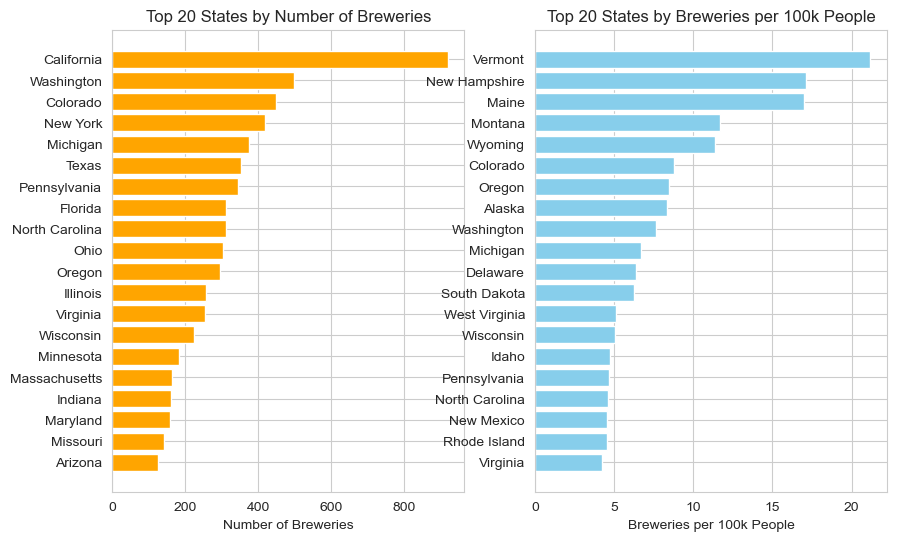

In [ ]:
# Rank top 20 states by brewery count and density in descending order
top20_counts = state_final.sort_values(by='total_breweries', ascending=False).head(20)
top20_density = state_final.sort_values(by='breweries_per_100k', ascending=False).head(20)

fig, ax = plt.subplots(1,2,figsize=(10, 6))
ax[0].invert_yaxis()
ax[0].barh(top20_counts['state'], top20_counts['total_breweries'], color='orange')
ax[0].set_xlabel('Number of Breweries')
ax[0].set_title('Top 20 States by Number of Breweries')

ax[1].invert_yaxis()
ax[1].barh(top20_density['state'], top20_density['breweries_per_100k'], color='skyblue')
ax[1].set_xlabel('Breweries per 100k People')
ax[1].set_title('Top 20 States by Breweries per 100k People')

This section examines brewery concentration across states. The left plot shows the raw count of Breweries for each state. As we can see, California seems to outnumber all other states in total brewery count, but when normalized to per 100,000 residents, Vermont has the highest density indicating a strong craft beer culture.

### 6.2 Density Map

In [ ]:
plot_map = state_final.copy()
state_to_abbr = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','District Of Columbia':'DC',
    'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID','Illinois':'IL',
    'Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
    'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
    'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR',
    'Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA',
    'Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}
plot_map['state_abbr'] = plot_map['state'].map(state_to_abbr)

fig = px.choropleth(
    plot_map,
    color_continuous_scale='Viridis',
    range_color=(0, 8),
    locations='state_abbr',
    locationmode='USA-states',
    color='breweries_per_100k',
    scope='usa',
    hover_name='state',
    hover_data={
        'total_breweries': True,
        'total_population': True,
        'breweries_per_100k': ':.2f',
        'state_abbr': False
    },
    title='Brewery Density by State (Breweries per 100k People)'
)
fig.show()

We plot a map of Brewery Density, and we can see the states with lighter color tend to have higher brewery density. This choropleth map provides a more intuitive view of regional brewery density patterns.

### 6.3 Brewery Type Breakdown

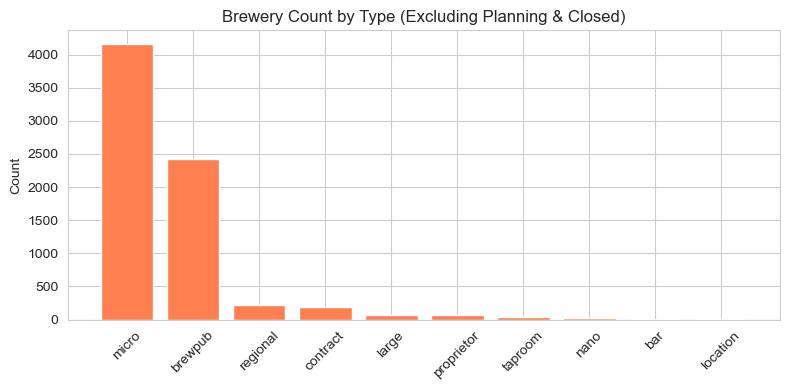

In [ ]:
# Count breweries by type (exclude planning and closed)
brewery_dropped = brewery_clean[~brewery_clean['brewery_type'].isin(['planning', 'closed'])]
brewery_type = brewery_dropped.groupby('brewery_type')['id'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(brewery_type.index, brewery_type.values, color='coral')
ax.set_ylabel('Count')
ax.set_title('Brewery Count by Type (Excluding Planning & Closed)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

If we group by type, we can see micro and brewpub are the two types most favored for investment.

### 6.4 Correlation between Population & Density

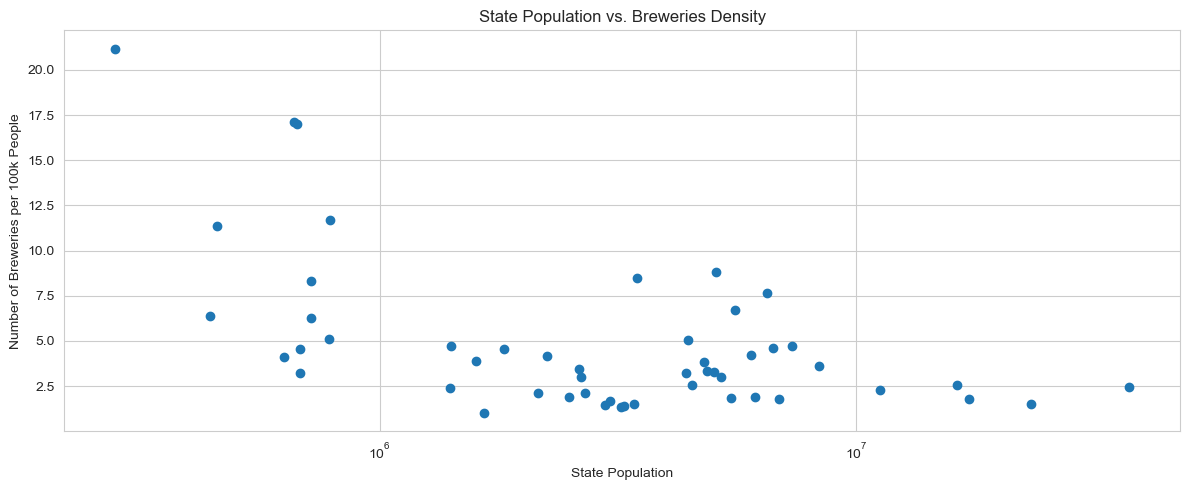

In [ ]:
plt.scatter(state_final['total_population'], state_final['breweries_per_100k'])
plt.xscale('log')
plt.xlabel('State Population')
plt.ylabel('Number of Breweries per 100k People')
plt.title('State Population vs. Breweries Density')
plt.tight_layout()
plt.show()

This scatterplot examines the relationship between population and density of Brewery. In smaller states, the density is higher. Conversely, in states with larger populations, the density is lower, which indicates that small states tend to have a high per-capita brewery count, and larger states tend to have a lower concentration of breweries relative to population.

Below, we further explore rent patterns through EDA.

### 6.5 Rent Distribution by State

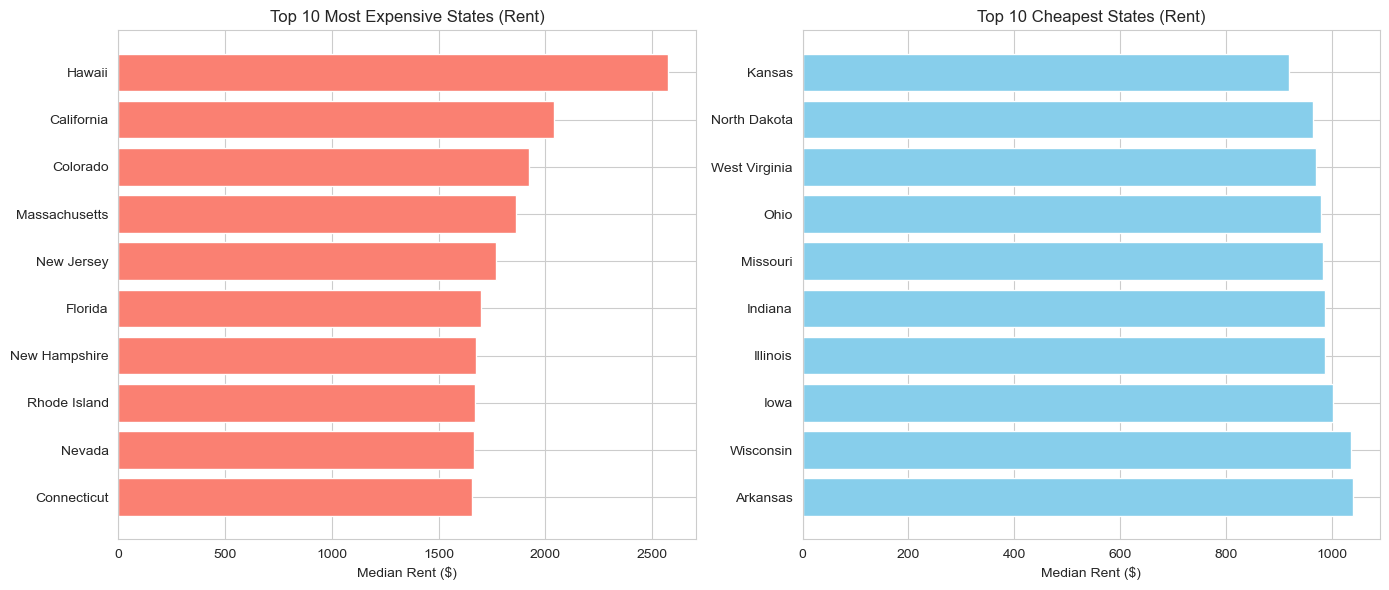

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 most expensive states
top10_rent = state_final.nlargest(10, 'mean_rent')
axes[0].barh(top10_rent['state'], top10_rent['mean_rent'], color='salmon')
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean Rent ($)')
axes[0].set_title('Top 10 Most Expensive States (Rent)')

# Top 10 cheapest states
bot10_rent = state_final.nsmallest(10, 'mean_rent')
axes[1].barh(bot10_rent['state'], bot10_rent['mean_rent'], color='skyblue')
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean Rent ($)')
axes[1].set_title('Top 10 Cheapest States (Rent)')

plt.tight_layout()
plt.show()

Median rent shows a clear regional clustering pattern as observed earlier and about 2.5 times more expensive than the cheapest rent states.

### 6.6 Rent vs Brewery Density

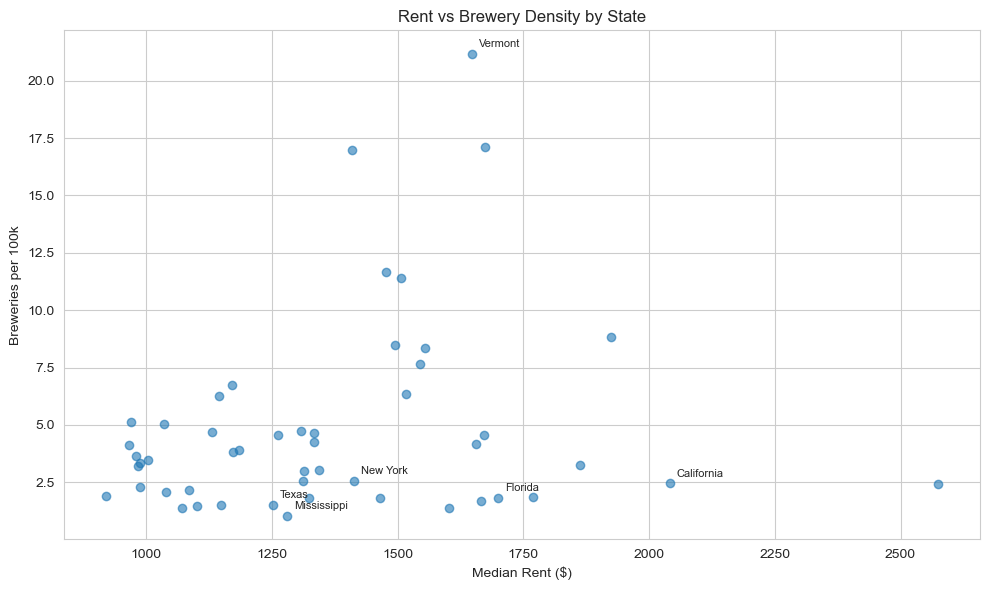

In [117]:
plt.figure(figsize=(10, 6))
plt.scatter(state_final['mean_rent'], state_final['breweries_per_100k'], alpha=0.6)
plt.xlabel('Mean Rent ($)')
plt.ylabel('Breweries per 100k')
plt.title('Rent vs Brewery Density by State')

# Annotate notable states
for _, row in state_final.iterrows():
    if row['state'] in ['California', 'Texas', 'Vermont', 'Mississippi', 'New York', 'Florida']:
        plt.annotate(row['state'],
                     (row['mean_rent'], row['breweries_per_100k']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

This scatterplot shows little linear relationship between Brewery density and rent, indicating that rent is not a significant deciding factor of the Brewery concentration.

### 6.7 Regional Comparison — Rent vs Density


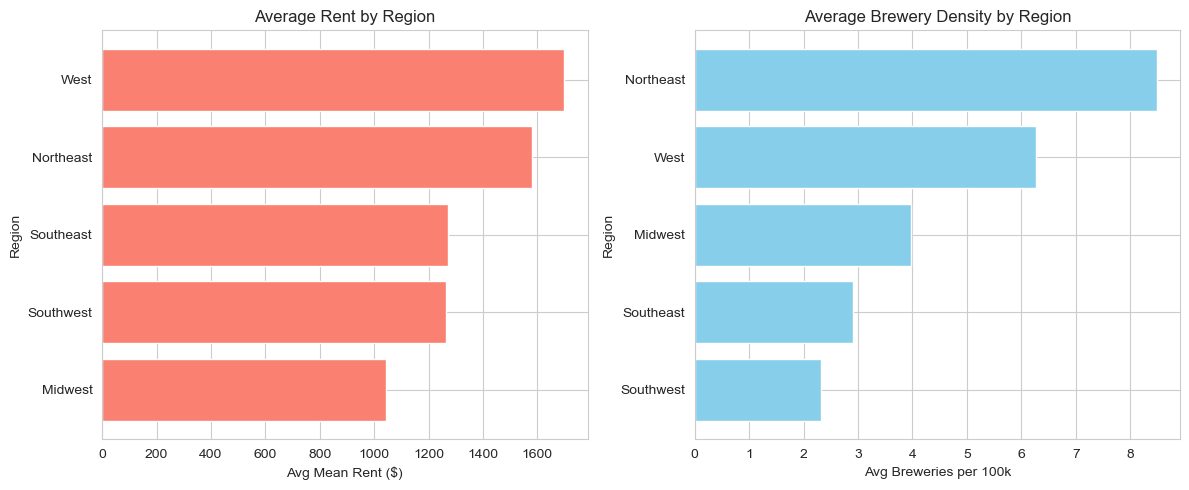

In [131]:
region_summary = state_final.groupby('region').agg(
    avg_rent   =('mean_rent',        'mean'),
    avg_density=('breweries_per_100k', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average Rent
rent_sorted = region_summary.sort_values('avg_rent')
axes[0].barh(rent_sorted['region'], rent_sorted['avg_rent'], color='salmon')
axes[0].set_title('Average Rent by Region')
axes[0].set_xlabel('Avg Mean Rent ($)')
axes[0].set_ylabel('Region')

# Average Brewery Density
density_sorted = region_summary.sort_values('avg_density')
axes[1].barh(density_sorted['region'], density_sorted['avg_density'], color='skyblue')
axes[1].set_title('Average Brewery Density by Region')
axes[1].set_xlabel('Avg Breweries per 100k')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()

This regional comparison further confirms that higher rent does not correlate with higher brewery density.

### 6.8 Updated Correlation Matrix (including Rent)

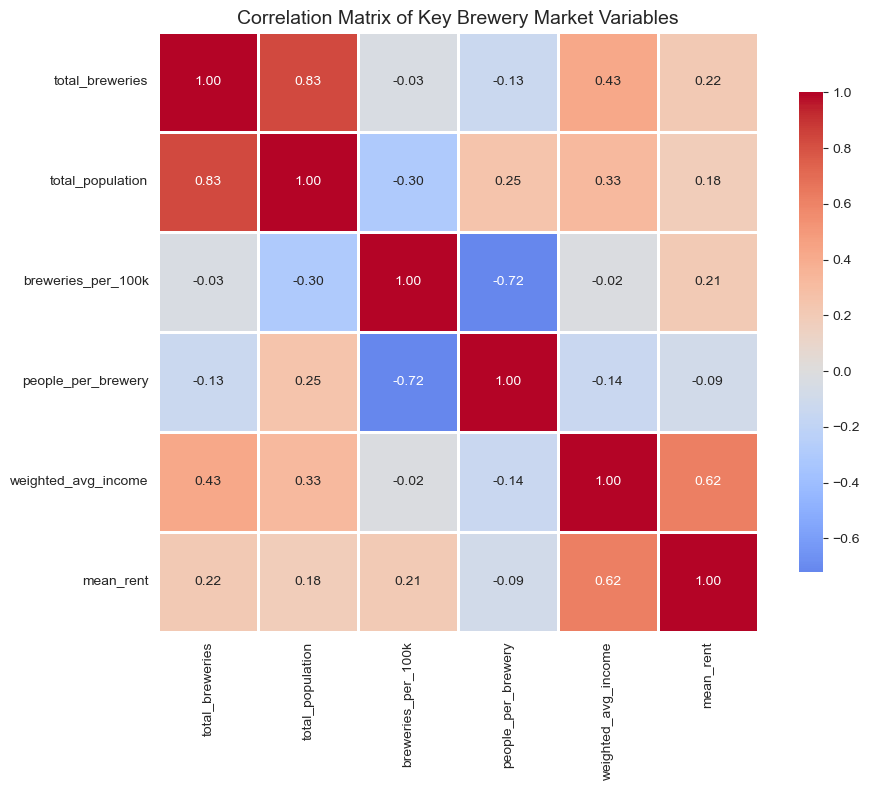


Key Insights from Correlation Matrix:
1. Strong positive correlation between total_population and total_breweries (r ≈ 0.83)
   → Larger states have more breweries in total
2. Negative correlation between total_population and breweries_per_100k (r ≈ -0.30)
   → Large states tend to have lower brewery density
3. Moderate correlation between weighted_average_income and total_breweries (r ≈ 0.43)
   → Wealthier states tend to have more breweries


In [119]:
corr_vars = [
    'total_breweries',
    'total_population',
    'breweries_per_100k',
    'people_per_brewery',
    'weighted_avg_income',
    'mean_rent'         
]

corr_matrix = state_final[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={'shrink': 0.8},
    fmt='.2f'
)
plt.title('Correlation Matrix of Key Brewery Market Variables', fontsize=14)
plt.tight_layout()
plt.show()

print('\nKey Insights from Correlation Matrix:')
print('1. Strong positive correlation between total_population and total_breweries (r ≈ {:.2f})'.format(
    corr_matrix.loc['total_population', 'total_breweries']))
print('   → Larger states have more breweries in total')
print('2. Negative correlation between total_population and breweries_per_100k (r ≈ {:.2f})'.format(
    corr_matrix.loc['total_population', 'breweries_per_100k']))
print('   → Large states tend to have lower brewery density')
print('3. Moderate correlation between weighted_average_income and total_breweries (r ≈ {:.2f})'.format(
    corr_matrix.loc['weighted_avg_income', 'total_breweries']))
print('   → Wealthier states tend to have more breweries')

The correlation matrix reveals several key patterns in the US brewery market across states. There is a strong positive correlation between total population and total number of breweries (r=0.83), indicating that larger states have more breweries in absolute terms. However, population shows a negative correlation with brewery density (r=-0.29), meaning that larger states tend to have fewer breweries per 100,000 people. This motivates adding rent as a cost variable and running regression to better understand the drivers of brewery density.

---
## 7. Linear Regression

### 7.1 Model 1 — Linear Regression
**Objective:** Identify which factors statistically drive brewery density (`breweries_per_100k`) across states.  The estimated coefficients are then used as data-driven weights in the final ranking model.

**Model:**
$$\log(\text{breweries\_per\_100k}) = \beta_0 + \beta_1 \log(\text{population}) + \beta_2 \log(\text{income}) + \beta_3 \log(\text{rent}) + \epsilon$$

With a sample size of only 50 states, a traditional train/test split would result in a test set too small to yield reliable generalization estimates. Therefore, we report **in-sample metrics** to characterize model goodness-of-fit rather than predictive performance.

In [120]:
# Prepare features — log transform
reg_df = state_final.copy()
reg_df['log_population'] = np.log1p(reg_df['total_population'])
reg_df['log_income']     = np.log1p(reg_df['weighted_avg_income'])
reg_df['log_rent']       = np.log1p(reg_df['mean_rent'])
reg_df['log_density']    = np.log1p(reg_df['breweries_per_100k'])

X = reg_df[['log_population', 'log_income', 'log_rent']]
y = reg_df['log_density']

# Standardize so coefficients are comparable as weights
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit regression
reg = LinearRegression()
reg.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature':     ['log_population', 'log_income', 'log_rent'],
    'coefficient': reg.coef_
})

# Model 1 — Full metrics
y_pred1 = reg.predict(X_scaled)

r2   = reg.score(X_scaled, y)
mae  = mean_absolute_error(y, y_pred1)
mse  = mean_squared_error(y, y_pred1)
rmse = np.sqrt(mse)

print('Model 1 Metrics')
print(f'  R²:        {r2:.4f}')
print(f'  MAE:       {mae:.4f}')
print(f'  MSE:       {mse:.4f}')
print(f'  RMSE:      {rmse:.4f}')
print(f'  Intercept: {reg.intercept_:.3f}')
print()
print(coef_df)

Model 1 Metrics
  R²:        0.3817
  MAE:       0.3580
  MSE:       0.1983
  RMSE:      0.4454
  Intercept: 1.585

          feature  coefficient
0  log_population    -0.364769
1      log_income     0.146216
2        log_rent     0.015079


Model 1 regresses log-transformed brewery density on three standardized predictors: population, income, and rent. 
- R² of 0.382, meaning it explains roughly 38% of the variation in brewery density across states, a moderate fit given the small sample size of 50 states and the complexity of real-world market dynamics.
- MAE of 0.358 and RMSE of 0.445 are on the log scale, indicating the model's predictions are within a reasonable range given the natural variation across states.
- Population is the strongest driver (coefficient = −0.365), with a negative sign indicating that while larger-population states may have a large absolute number of breweries, their growth rate cannot keep up with their population size, resulting in a lower per capita density.
- Income shows a positive relationship (coefficient = 0.146), suggesting that wealthier states tend to support higher brewery density, consistent with craft beer being a discretionary spend. 
- Rent has a near-zero coefficient (0.015), implying that at the state level, rent alone does not meaningfully predict brewery concentration.

### 7.2 Model 2 — Linear Regression with Region Controls

**Objective:** Extend Model 1 by adding region dummy variables (OHE) as controls. This allows us to check whether regional effects explain additional variation in brewery density beyond population, income, and rent.


**Model:**
$$\log(\text{breweries\_per\_100k}) = \beta_0 + \beta_1 \log(\text{population}) + \beta_2 \log(\text{income}) + \beta_3 \log(\text{rent}) +  \beta_4 \text{ region dummies} + \epsilon$$

Comparing R² between Model 1 and Model 2 tells us how much of the variation is explained by geography vs. economic factors.

In [121]:
# Add region dummies to reg_df
reg_df2 = reg_df.copy()
reg_df2['region'] = reg_df2['state'].map(
    state_final.set_index('state')['region']
)
region_dummies = pd.get_dummies(reg_df2['region'], prefix='region', drop_first=True)
reg_df2 = pd.concat([reg_df2, region_dummies], axis=1)

# Features: log vars + region dummies
region_cols = region_dummies.columns.tolist()
X2 = reg_df2[['log_population', 'log_income', 'log_rent'] + region_cols].dropna()
y2 = reg_df2.loc[X2.index, 'log_density']

# Standardize only the continuous features
X2_scaled = X2.copy()
X2_scaled[['log_population', 'log_income', 'log_rent']] = StandardScaler().fit_transform(
    X2[['log_population', 'log_income', 'log_rent']]
)

# Fit Model 2
reg2 = LinearRegression()
reg2.fit(X2_scaled, y2)

# Compare Model 1 vs Model 2
r2_model1 = reg.score(X_scaled, y)
r2_model2 = reg2.score(X2_scaled, y2)

print('Model Comparison:')
print(f'  Model 1 (population + income + rent):          R² = {r2_model1:.3f}')
print(f'  Model 2 (+ region dummies):                    R² = {r2_model2:.3f}')
print(f'  Improvement from adding region controls:       ΔR² = {r2_model2 - r2_model1:.3f}')

Model Comparison:
  Model 1 (population + income + rent):          R² = 0.382
  Model 2 (+ region dummies):                    R² = 0.476
  Improvement from adding region controls:       ΔR² = 0.094


In [122]:
# Model 2 — Full metrics
y_pred2 = reg2.predict(X2_scaled)

mae2  = mean_absolute_error(y2, y_pred2)
mse2  = mean_squared_error(y2, y_pred2)
rmse2 = np.sqrt(mse2)

print()
print('Model 2 Full Metrics')
print(f'  R²:   {r2_model2:.4f}')
print(f'  MAE:  {mae2:.4f}')
print(f'  MSE:  {mse2:.4f}')
print(f'  RMSE: {rmse2:.4f}')


Model 2 Full Metrics
  R²:   0.4759
  MAE:  0.3338
  MSE:  0.1681
  RMSE: 0.4100


Model 2 extends Model 1 by adding region dummy variables (Northeast, Midwest, Southwest, West, with Southeast as the reference category). 
- R² improves from 0.382 to 0.476, a gain of 0.094, indicating that regional effects explain an additional 9.4% of the variation in brewery density beyond what economic factors alone capture.
- MAE drops from 0.358 to 0.334 and RMSE drops from 0.445 to 0.410, confirming that the region controls meaningfully sharpen the model's predictions.

The moderate improvement suggests that both economic factors and regional culture/geography matter. States in certain regions such as the West and Northeast tend to have higher brewery density even after controlling for population, income, and rent; likely reflecting regional craft beer culture, favorable regulatory environments, or consumer preferences that are not fully captured by economic variables alone. 

**Model 2 is the preferred specification**; its region-controlled coefficients are used as composite score weights to account for regional heterogeneity.

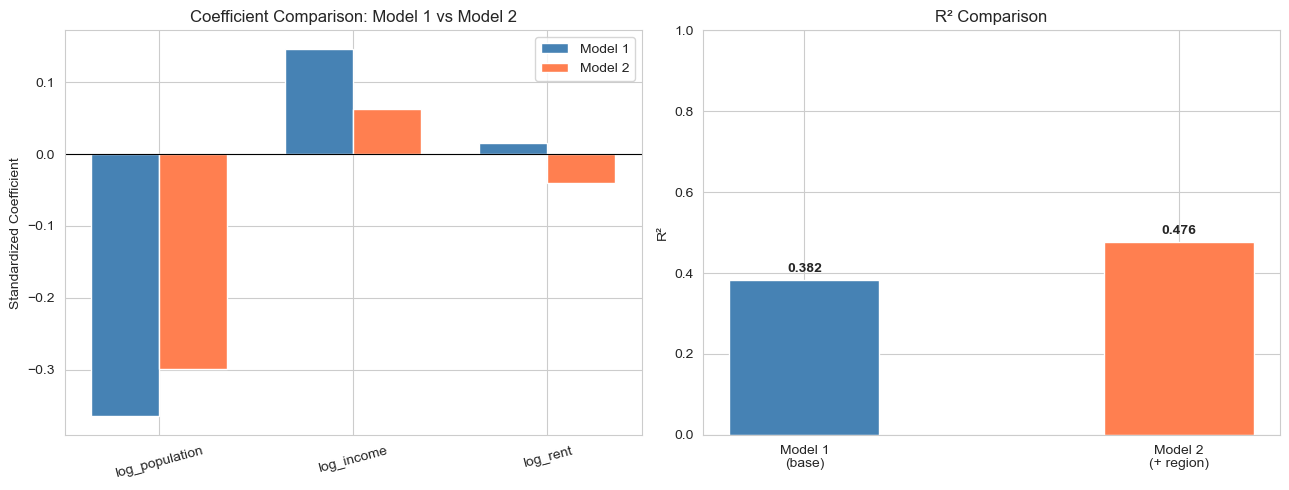

In [123]:
# Visualize: Model 1 vs Model 2 coefficients side by side
coef_m1 = pd.DataFrame({
    'feature': ['log_population', 'log_income', 'log_rent'],
    'Model 1': reg.coef_
})
coef_m2 = pd.DataFrame({
    'feature': ['log_population', 'log_income', 'log_rent'],
    'Model 2': reg2.coef_[:3]  # first 3 are the continuous vars
})
coef_compare = coef_m1.merge(coef_m2, on='feature')

x = range(len(coef_compare))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coefficient comparison
axes[0].bar([i - width/2 for i in x], coef_compare['Model 1'], width, label='Model 1', color='steelblue')
axes[0].bar([i + width/2 for i in x], coef_compare['Model 2'], width, label='Model 2', color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(coef_compare['feature'], rotation=15)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Coefficient Comparison: Model 1 vs Model 2')
axes[0].set_ylabel('Standardized Coefficient')
axes[0].legend()

# R² comparison
axes[1].bar(['Model 1\n(base)', 'Model 2\n(+ region)'], [r2_model1, r2_model2],
            color=['steelblue', 'coral'], width=0.4)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('R²')
axes[1].set_title('R² Comparison')
for i, v in enumerate([r2_model1, r2_model2]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

After incorporating **region controls**, the coefficient for rent flips from positive to negative. This suggests that once regional differences are controlled for, states with higher rents within the same region actually exhibit lower brewery density. This aligns with economic intuition, as rent represents a cost barrier that inhibits entry. The positive coefficient in Model 1 was likely driven by omitted variable bias, where high-rent states (e.g., NY, CA) are also high-income/highly developed, thus confounding the **income effect** with rent. Adding region controls in Model 2 allows us to isolate the effect of economic factors (population, income, rent) from geographic clustering. 

---
## 8. Final Ranking & Recommendation

The raw coefficients vary in sign, and using them directly would cause negative weights (e.g., population) to penalize the composite score. However, since a larger population represents greater market opportunity, we want these states to score higher. Therefore, we take the absolute value of the coefficients and manually adjust their polarity (direction) during the scoring phase.

In [124]:
# Derive weights from coefficients
# Use absolute values so direction is handled separately in scoring
abs_coefs = np.abs(reg2.coef_[:3]) 
weights   = abs_coefs / abs_coefs.sum()

w_population = weights[0]
w_income     = weights[1]
w_rent       = weights[2]

print('weights from regression:')
print(f'  Population (market size):  {w_population:.2%}')
print(f'  Income (purchasing power): {w_income:.2%}')
print(f'  Rent (cost):               {w_rent:.2%}')

weights from regression:
  Population (market size):  74.24%
  Income (purchasing power): 15.64%
  Rent (cost):               10.12%


Since the regression identifies population as the dominant driver (negative coefficient = larger states are underserved), we use `people_per_brewery` as the scoring proxy for this dimension — it directly captures the degree to which a state's market is underserved per existing brewery, which is the investor-relevant interpretation of the population signal.

In [125]:
# Rank-based composite score
# people_per_brewery: high rank = underserved = good
# weighted_avg_income: high rank = high income = good
# mean_rent: low rank = cheap rent = good (invert)
state_final['pop_norm']    = state_final['people_per_brewery'].rank(pct=True)
state_final['income_norm'] = state_final['weighted_avg_income'].rank(pct=True)
state_final['rent_norm']   = state_final['mean_rent'].rank(pct=True)

# Composite score using regression-derived weights
state_final['composite_score'] = (
    w_population * state_final['pop_norm'] +
    w_income     * state_final['income_norm'] +
    w_rent       * (1 - state_final['rent_norm'])  # invert rent: lower rent = better
)

# Final top 10
top10_final = state_final.nlargest(10, 'composite_score')[[
    'state', 'composite_score',
    'people_per_brewery', 'weighted_avg_income',
    'mean_rent', 'breweries_per_100k'
]].reset_index(drop=True)
top10_final.index += 1
print('Top 10 Recommended States for New Brewery Investment:')
top10_final


Top 10 Recommended States for New Brewery Investment:


,state,composite_score,people_per_brewery,weighted_avg_income,mean_rent,breweries_per_100k
1,Utah,0.869472,72460.088889,98563.180535,1601.923826,1.380070
2,Texas,0.843825,66134.150568,79958.828372,1252.178632,1.512078
3,Oklahoma,0.825259,72971.727273,64852.758710,1071.541120,1.370394
4,Mississippi,0.802203,97337.470588,54917.474151,1279.838792,1.027354
5,Louisiana,0.782131,67712.613636,58729.378342,1100.933409,1.476830
6,Arizona,0.766400,55204.952000,83511.734264,1465.823731,1.811432
7,Nevada,0.763345,59811.843137,78515.663123,1665.841029,1.671910
8,Alabama,0.762002,65732.076923,67313.745276,1148.726965,1.521327
9,Kansas,0.756449,53061.106383,75977.501668,920.222480,1.884620
10,New Jersey,0.749031,53283.765217,104574.842270,1768.992699,1.876744


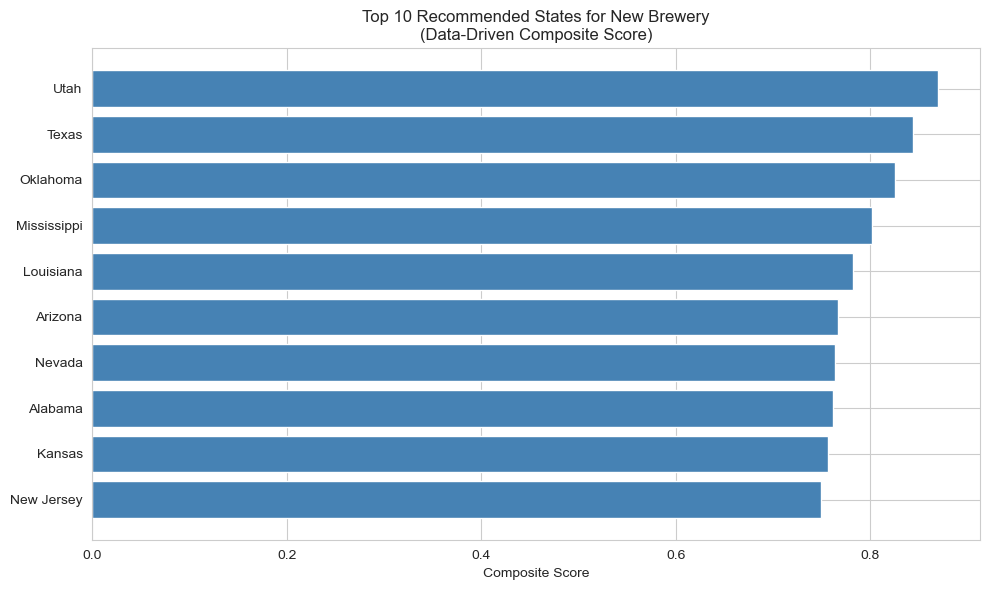

In [126]:
# Visualize final ranking
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_final['state'], top10_final['composite_score'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Composite Score')
ax.set_title('Top 10 Recommended States for New Brewery\n(Data-Driven Composite Score)')
plt.tight_layout()
plt.show()

In [128]:
print('Top 10 States')
print(top10_final[['state', 'composite_score']].to_string(index=True))

Top 10 States
          state  composite_score
1          Utah         0.869472
2         Texas         0.843825
3      Oklahoma         0.825259
4   Mississippi         0.802203
5     Louisiana         0.782131
6       Arizona         0.766400
7        Nevada         0.763345
8       Alabama         0.762002
9        Kansas         0.756449
10   New Jersey         0.749031


In [129]:
print('Regional Avg Density')
print(state_final.groupby('region')['breweries_per_100k'].mean().sort_values().to_string())

Regional Avg Density
region
Southwest    2.311261
Southeast    2.915570
Midwest      3.974377
West         6.273165
Northeast    8.487964


---
## 9. Conclusion

### Key Findings

1. **Top recommended states** for opening a new brewery are **Utah, Texas, and Oklahoma**, based on a composite score that weights market underservice (people per brewery), purchasing power (median household income), and cost of entry (mean rent) using regression-derived weights. These states combine large, underserved populations with strong income levels and relatively affordable rent.

2. **Regression results**: 
    - **Model 1** show that population is the strongest driver of brewery density (standardized coefficient = −0.365), followed by income (0.146) and rent (0.015). The negative population coefficient indicates that larger states are currently *underserved* on a per-capita basis — representing untapped market opportunity rather than saturation. Model 1 explains 38.2% of variance in brewery density (R² = 0.382).

    - **Model 2** (with region dummy controls) improves R² to 0.476, a gain of 9.4 percentage points. This confirms that regional culture and geography matter beyond economic factors alone — states in the West and Northeast show structurally higher brewery density even after controlling for population, income, and rent. Model 2 is the preferred specification; its region-controlled coefficients are used as composite score weights to account for regional heterogeneity.

2. **Regional patterns**: The Southwest (avg density = 2.31 breweries per 100k) and Southeast (2.92) are the most underserved regions, while the Northeast (8.49) and West (6.27) are already highly saturated. For investors prioritizing lower competition, Southwest and Southeast states offer the strongest entry opportunity.

### Recommendations
- **Where:** Utah, Texas, and Oklahoma rank highest on the data-driven composite score.
- **Why:** Regression confirms that market size (population) and purchasing power (income) are far more important location drivers than rent — accounting for 74% and 16% of the 
  composite weight respectively. These states offer large underserved markets with strong consumer spending capacity.
- **Type:** Based on the brewery type breakdown in Section 6.3, **microbreweries** and **brewpubs** dominate the market. New entrants should consider one of these two formats to align with proven consumer preferences.

### Limitations
- State-level analysis (n = 51) limits regression power; a **city-level model** using Zillow city data and city-level Census estimates would yield more actionable insights for site selection.
- The dataset is **cross-sectional** — adding time-series data on brewery openings and closures would allow trend analysis and survival modeling.
- **Rent data from Zillow** reflects residential rents and may not fully capture commercial lease costs, which are more directly relevant to brewery operations.
- Additional datasets that would strengthen the analysis include: state-level beer consumption per capita, local zoning and licensing regulations, and tourist foot traffic data near commercial districts.
  
### AI-use disclosure
AI was used to assist with code structure, SQL query design, and markdown write-up drafting. All analytical decisions, model specifications, and interpretations were made by the project team.